In [ ]:
import pickle
import io, time
from io import BytesIO
from IPython.display import display
import pickle, tarfile, random, re, requests
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', -1)

import sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression

import torch
from transformers import * # here introduces bert
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings("ignore")


In [5]:
from data_structure import Dataset, SentenceEdit, get_IMDB, get_kindle, get_toxic_comment, get_toxic_tw


In [41]:
#Get data and top words

def simple_vectorize(df):
    """
    Vectorize text
    """
    vec = CountVectorizer(min_df=5, binary=True, max_df=.8)
    X = vec.fit_transform(df.text)
    print(X.shape)
    y = df.label.values
    feats = np.array(vec.get_feature_names_out())
    
    return X, y, vec, feats

In [158]:
def print_coef(clf, feats, n=10, pattern=None):
    """
    sort and print words by coef stregth (abs(coef))
    """
    if len(clf.classes_) == 2:
        coefs = [-1*clf.coef_[0], clf.coef_[0]] # change the coef relation corresponding with each class
    else:
        coefs = clf.coef_

    for label, coef in zip(clf.classes_, coefs):
        print("\nTop features for class %s" % str(label))
        if pattern:
            # restrict to features matching pattern
            coef = coef.copy()
            coef[[i for i,s in enumerate(feats) if len(re.findall(pattern, s)) == 0]] = 0
        
        topi = coef.argsort()[::-1][:n]
        s = ' '.join('%s/%.2f' % (f,c) for f, c in zip(feats[topi], coef[topi]))
        print(s)
        
def get_top_terms(dataset, coef_thresh=.5, placebo_thresh=.5, C=1):
    """
    Fit classifier, print top-n terms;
    Top features (features have high coef): abs(coef) >= thresh
    Placebos (features have low coef): abs(coef) <= thresh
    """
    clf = LogisticRegression(class_weight='balanced', C=C, solver='lbfgs', max_iter=1000)
    clf.fit(dataset.X, dataset.y)
    
    print_coef(clf, dataset.feats, n=100)
    #print('dummy coef= %.3f' % clf.coef_[0][dataset.vec.vocabulary_[DUMMY_TERM]])
    
    top_feature_idx = np.where(abs(clf.coef_[0]) >= coef_thresh)[0]
    placebo_feature_idx = np.where(abs(clf.coef_[0]) <= placebo_thresh)[0]
    feature_coef = np.array([float("%.3f" % c) for c in clf.coef_[0]]) 
    
    return top_feature_idx, placebo_feature_idx, feature_coef

In [159]:
def get_wd_context(sentence, word, window=5):
    """
    Remove word from sentence and return context (at most 5 tokens before and after the word)
    E.g.,
        word: delicious 
        sentence: Love this book full of delicious foods
        context: Love this book full of ... foods (at most 5 (window size) left and right words)
        
    """
    word = word.lower()
    toks = sentence.split()
    
    for i, t in enumerate(toks):
        if re.search(r'(?i)\b%s\b' % word, t): # if find the word, then take left 5 and right 5 words
            s = ' '.join(toks[max(0, i-window):min(i+window+1, len(toks)-1)])
            return re.sub(r'(?i)\b%s\b' % word, ' ', s, re.IGNORECASE)
        
def remove_wd_from_sentences(X, sentences, labels, vec, remove_wd_list, exclude_sent_idx, window=5):
    """
    for each word to be removed
      for each treatment sentence (sentence containing this word)
        make a copy of the sentence with this word removed
        
    remove_wd_list:
        - top_words: abs(coef) > thresh
        - placebo_words: abs(coef) < thresh
    exclude_sent_idx:
        - sentences to exclude (sentences containing placebo_words should not contain top_words)
    
    X: feature matrix;
    sentences: a list of sentences containing keywords;
    labels: sentence labels;
    all_words: words to be removed;
    vec: CountVectorizer;
    window: number of tokens to keep before and after the removing word
    
    unk sentence: sentence with a specific word removed;
        E.g., "Love this book full of delicious foods"
              "Love this book full of ... foods"
                
    returns:
       unk_sentences: a list of SentenceEdit objects
       word2sentences: map from word to a list of SentenceEdit objects related with this word
       sentence_idx: list of processed sentence ids 
       
    """
    word2sentenceEdit = defaultdict(list)
    sentenceEdit_objs = []
    sentence_idx = []
    
    for word in remove_wd_list:
        wi = vec.vocabulary_[word]
        for sent_id in X[:,wi].nonzero()[0]: # sentences containing current word
            if(sent_id not in exclude_sent_idx): # not contain any top words
                wd_context = get_wd_context(sentences[sent_id], word, window) # context within window=5
                sEdit_obj = SentenceEdit(wd_context, sent_id, word, labels[sent_id])
                word2sentenceEdit[word].append(sEdit_obj)
                sentenceEdit_objs.append(sEdit_obj)
                sentence_idx.append(sent_id)
                
#     print('%d sentences with placebo terms\n' % len(unk_sentences))

    return sentenceEdit_objs, word2sentenceEdit, list(set(sentence_idx))


In [160]:
def get_original_sentences(df):
    """
    Original sentences without any word removed;
    Used when control case is not removing any word;
    """
    df['i_th'] = range(df.shape[0])
    original_sentEdit = []
    for ri, row in df.iterrows():
        sEdit_obj = SentenceEdit(row['text'], row['i_th'], '', row['label'])
        original_sentEdit.append(sEdit_obj)
        
    return original_sentEdit

In [161]:
def embed_one_sentence(sentence, sentence_model, tokenizer):
    """
    # bert_tokenizer.vocab_size
    # bert_tokenizer.tokenize(sentence)
    # bert_tokenizer.convert_tokens_to_ids('on')
    # bert_tokenizer.convert_ids_to_tokens(102)
    # each sentence is encoded as a 3072 vec: 768 * 4 (concat last four layers)
    """
    with torch.no_grad():
        # sentence_model returns (logit output layer, pooler_output, hidden states, attentions)
        hidden_states = sentence_model(torch.tensor([tokenizer.encode(sentence, add_special_tokens=True)]))[2]
        #last_four_layers = [hidden_states[i] for i in (-1, -2, -3, -4)]
        last_four_layers = [hidden_states[i] for i in (0,1,2,3)] # list of 4 element, each element is [1,16,768]
        # cast layers to a tuple and concatenate over the last dimension
        cat_hidden_states = torch.cat(tuple(last_four_layers), dim=-1) # [1,16,3072]
        cat_sentence_embedding = torch.mean(cat_hidden_states, dim=1).squeeze() # 3027
        #return(torch.mean(hidden_states[-1], dim=1).squeeze()) # average word embeddings in last layer
        return cat_sentence_embedding.numpy()                         # average last 4 layers
        
        
def embed_all_sentences(sentences, bert_tokenizer=None, sentence_model=None):
    """
    sentences: a list of SentenceEdit objects;
    Each sentence is a SentenceEdit object;
    Add embedding attribute for SentenceEdit object;
    """
    if not bert_tokenizer:
        bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        sentence_model = BertModel.from_pretrained('bert-base-uncased',output_hidden_states=True, output_attentions=True)
    
    for s in tqdm(sentences):
        s.embedding = embed_one_sentence(s.context, sentence_model, bert_tokenizer)

In [162]:
#checkpoint till here
def get_dataset_embeddings():
    """
    1. Get data from file and construct DataSet object
    2. Get top words, placebo words
    3. Edit sentences and get embeddings for edited sentences:
        Remove top words;
        Remove placebo words;
        Original sentences without edit;
    """
    random.seed(42)
    datasets = []
    for get_data_df, moniker, coef_thresh, placebo_thresh in [
            (get_IMDB, 'imdb', 1.0, 0.1),
            (get_kindle, 'kindle', 0.9, 0.2),
            (get_toxic_comment, 'toxic', 1.0, 0.05), 
            (get_toxic_tw, 'toxic_tw', 0.7, 0.2),
        ]: 
        
        # Get data and show basic information
        df = get_data_df()
        X, y, vec, feats = simple_vectorize(df) # vectorize text
        ds = Dataset(X, y, vec, df, moniker) # construct dataset object
        
        print('%s dataset, %d instances' % (moniker,len(df)))
        print('Label distribution: %s' % str(Counter(y).items()))
        print('Feature matrix: %s' % str(X.shape))
        
        # Get top features 
        ds.top_feature_idx, ds.placebo_feature_idx, ds.coef = get_top_terms(ds, coef_thresh=coef_thresh, placebo_thresh=placebo_thresh, C=1)
        ds.top_features = feats[ds.top_feature_idx]
        ds.placebo_features = feats[ds.placebo_feature_idx]
        print('\n%d top terms: %d pos, %d neg\n' % (len(ds.top_features), len(np.where(ds.coef[ds.top_feature_idx]>0)[0]), len(np.where(ds.coef[ds.top_feature_idx]<0)[0])))
        print('\n%d placebo terms: %d pos, %d neg\n' % (len(ds.placebo_features), len(np.where(ds.coef[ds.placebo_feature_idx]>0)[0]), len(np.where(ds.coef[ds.placebo_feature_idx]<0)[0])))
        
        # Edit sentences (remove top features, placebo features, keep as it is) and get embedding representations
        
#         print('Edit sentences containing top words')                                                                   
        ds.topwd_sentObj_list, ds.topwd_sentObj_dict, topwd_sent_idx = remove_wd_from_sentences(X,df.text,df.label,vec,ds.top_features,exclude_sent_idx=[])
        print('Edit %d sentences for top terms\n' % len(ds.topwd_sentObj_list))
        embed_all_sentences(ds.topwd_sentObj_list) 

#         print('Edit sentences containing placebo words')     
        ds.placebowd_sentObj_list, ds.placebowd_sentObj_dict, placebowd_sent_idx = remove_wd_from_sentences(X,df.text,df.label,vec,ds.placebo_features,topwd_sent_idx)
        print('Edit %d sentences for placebo terms\n' % len(ds.placebowd_sentObj_list))
        embed_all_sentences(ds.placebowd_sentObj_list) 
        
#         print('Original sentences convert to sentence edit object')
        ds.original_sentObj_list = get_original_sentences(df)
        print('%d original sentences')
        embed_all_sentences(ds.original_sentObj_list)    
        
        datasets.append(ds)
        
    return datasets

In [163]:
# define the data structure and read data from file


import requests, tarfile
from io import BytesIO
import pandas as pd
import pickle
import numpy as np
import random

class Dataset:
    def __init__(self, X, y, vec, df, moniker):
        """
        X: feature matrix;
        y: labels;
        vec: CountVectorizer
        df: dataframe
        feats: features from CountVectorizer
        moniker: reference name to the dataset
        """
        print('new dataset with %d records' % len(df))
        display(df.head(1))
        self.X = X
        self.y = y
        self.vec = vec
        self.df = df
        self.feats = np.array(vec.get_feature_names_out())
        self.moniker = moniker # name of the dataset
        

class SentenceEdit:
    def __init__(self, context, sentence_idx, remove_wd, label):
        """
        Remove a word from a sentence;
        E.g., 
            remove_wd: delicious 
            sentence: Love this book full of delicious foods
            context: Love this book full of  foods (at most 5 (window size) left and right words)
        """
        self.remove_wd = remove_wd
        self.context = context
        self.sentence_idx = sentence_idx
        
        self.label = label
        self.cluster_id = -1
      
    def __repr__(self):
        return '%s / %s / %s' % (self.remove_wd, str(self.label), self.context)
    
def get_IMDB():
    """
    Get IMDB movie reviews from the link;
    Sentences labeled as pos and neg
    
    """
    data_url = 'http://www.cs.cornell.edu/people/pabo/movie-review-data/rt-polaritydata.tar.gz'

    web_response = requests.get(data_url, stream=True)
    gz_file = web_response.content # Content in bytes from requests.get, see comments below why this is used.
    zipfile = tarfile.open(fileobj=BytesIO(gz_file))
    neg_file = zipfile.extractfile('rt-polaritydata/rt-polarity.neg')
    pos_file = zipfile.extractfile('rt-polaritydata/rt-polarity.pos')
    df = pd.DataFrame([{'label': -1, 'text': t.decode("cp437").strip() } for t in neg_file] +
                      [{'label': 1, 'text': t.decode("cp437").strip()} for t in pos_file])

    return df


def get_kindle():
    """
    Kindle book reviews with sentiment labels;
    Pre-processed by:
        Split comments into sentences;
        Filter by keywords;
        Limit sentence length [5,50];
    """
    df = pickle.load(open("data/kindle_unique_sents.pkl",'rb'))
#     df = df.sample(frac=1)
    df.reset_index(drop=True,inplace=True)
        
    return df

# def get_toxic_comment(limit_length=False):
#     """
#     Toxic comment from wikipedia talk page;
#     target (toxic score) > 0.7 as 1
#     target (toxic score) < 0.5 as -1
#     """
#     data_url = 'https://www.dropbox.com/s/hy80mvdsf3jgzw5/toxic.csv?dl=1'
#     web_response = requests.get(data_url, stream=True)
#     df = pd.read_csv(io.StringIO(web_response.text))[['id','target','text','label']]
    
#     if(limit_length):
#         df['text_len'] = df['text'].apply(lambda x: len(x.split()))
#         df_select = df[(df['text_len']<65)]
#         pos_idx = random.sample(list(df_select[df_select['label']==1]['id'].values),5000)
#         neg_idx = random.sample(list(df_select[df_select['label']==-1]['id'].values),5000)

#         df = df_select[df_select['id'].isin(list(pos_idx)+list(neg_idx))]
#         df.reset_index(drop=True,inplace=True)
        
#     return df
# importing the file directly instead

def get_toxic_comment():
    df = pickle.load(open("data/toxic_short_sents.pickle",'rb'))
    df = df.sample(frac=1)
    df.reset_index(drop=True,inplace=True)
    
    return df


def get_toxic_tw():
    """
    Toxic tweets from paper: Characterizing Variation in Toxic Language by Social Context
    """
    random.seed(42)
    df = pd.read_csv(open("data/toxic_tweets.csv"))
    df['label'] = df['hostile'].apply(lambda x: 1 if x==1 else -1)
    
    return df[['id','text','label']]

In [ ]:
#this gonna take some while to run
start = time.time()
datasets = get_dataset_embeddings()
end = time.time()
print((end-start)/60)

In [ ]:
pickle.dump(datasets, open('data/datasets_emb.pickle','wb'))

In [48]:
def find_matched_sentence(t_sentObj, c_sentObj_list, min_sim=.7):
    """
    For each treatment sentence (sentence contain a top word), find a matched sentence (sentences with similar contexts);
        
    Find the sentence with closest contexts:
    context_A = sentence_A - word_A
    context_B = sentence_B - word_B
    
    for context_A:
        sort similarity score of (context_A, all other contexts) in descending order
        if((sentence_A != sentence_B) and (word_A != word_B) and (cos(context_A,context_B)>0.7)):
            context_B is a match for context_A
    
    diff: difference between sentence_A.label - sentence_B.label
    """
    
    # similarity between current treatment context with all other contexts
    sims = cosine_similarity([t_sentObj.embedding],[c_sent.embedding for c_sent in c_sentObj_list])[0]
    
    match = None
    match_sim = 0
    for c_sentObj, sim in sorted(zip(c_sentObj_list, sims), key=lambda x: -x[1]): # find the first most similar match
        if((sim >= min_sim) and (c_sentObj.sentence_idx != t_sentObj.sentence_idx) and (c_sentObj.remove_wd != t_sentObj.remove_wd) and (not re.search(r'(?i)\b%s\b' % t_sentObj.remove_wd, c_sentObj.context))):
            match = c_sentObj
            match_sim = sim        
            break
            
    if match:
        diff = (t_sentObj.label - match.label)
    else:
        print('no match')
        diff = 0
#         diff = np.nan

    return diff, match_sim, match # [(match_sim, target_sentence)], [(match_sim,match)]

In [49]:
def calculate_ites_from_matched_sentences(ds_data, matchby='treat', min_sim=0.01):
    """
    For each treatment sentence (sentence contain a top word), find a matched sentence (sentences with similar contexts);
    
    t_sentObj_list: a list of SentenceEdit objects for sentences with top words removed
    c_sentObj_list: a list of SentenceEdit objects for sentences with top / placebo / '' words removed
    matchby = treat / control / placebo
    """
    t_sentObj_list = ds_data.topwd_sentObj_list
    
    if(matchby == 'treat'):
        c_sentObj_list = ds_data.topwd_sentObj_list
    elif(matchby == 'placebo'):
        c_sentObj_list = ds_data.placebowd_sentObj_list
    elif(matchby == 'control'):
        c_sentObj_list = ds_data.original_sentObj_list
    
    matched_pairs = []    
    for t_sentObj in tqdm(t_sentObj_list):
        ite_bylabel, sim, control_obj = find_matched_sentence(t_sentObj, c_sentObj_list, min_sim=min_sim)
            
        matched_pairs.append(
            {
                'term': t_sentObj.remove_wd,
                'sentence_id': t_sentObj.sentence_idx,
                'treat_obj': t_sentObj,
                'control_obj': control_obj, # this is an object             
                'similarity': sim,
                'difference': t_sentObj.embedding - control_obj.embedding, 
                'ite': ite_bylabel,
            }
        )
    return pd.DataFrame(matched_pairs)

In [101]:
ds_imdb, ds_kindle, ds_toxic, ds_toxic_tw = pickle.load(open('data/datasets_emb.pickle','rb'))


In [42]:
ds_imdb, ds_kindle, ds_toxic, ds_toxic_tw = pickle.load(open('data/datasets_emb.pickle','rb'))
datasets = [ds_imdb, ds_kindle, ds_toxic, ds_toxic_tw]

 
start = time.time()
data_ites_byTreat = []
for ds_data in datasets:
    ds_data.ites = calculate_ites_from_matched_sentences(ds_data, matchby='treat', min_sim=0.01)
    data_ites_byTreat.append(ds_data)
    
end = time.time()
print((end-start)/60)
pickle.dump(data_ites_byTreat, open('data/datasets_treat_match.pickle', 'wb'))

  0%|          | 0/8777 [00:00<?, ?it/s]

  0%|          | 0/29617 [00:00<?, ?it/s]

  0%|          | 0/8230 [00:00<?, ?it/s]

  0%|          | 0/9253 [00:00<?, ?it/s]

246.895252597332


In [43]:
start = time.time()

data_ites_byPlacebo = []
for ds_data in datasets:
    ds_data.ites = calculate_ites_from_matched_sentences(ds_data, matchby='placebo', min_sim=0.01)
    data_ites_byPlacebo.append(ds_data)
    
end = time.time()
print((end-start)/60)
pickle.dump(data_ites_byPlacebo, open('data/datasets_placebo_match.pickle', 'wb'))


  0%|          | 0/8777 [00:00<?, ?it/s]

  0%|          | 0/29617 [00:00<?, ?it/s]

  0%|          | 0/8230 [00:00<?, ?it/s]

  0%|          | 0/9253 [00:00<?, ?it/s]

79.24216043154398


In [44]:
start = time.time()

data_ites_byControl = []
for ds_data in datasets:
    ds_data.ites = calculate_ites_from_matched_sentences(ds_data, matchby='control', min_sim=0.01)
    data_ites_byControl.append(ds_data)

end = time.time()
print((end-start)/60)
pickle.dump(data_ites_byControl, open('data/datasets_control_match.pickle', 'wb'))

  0%|          | 0/8777 [00:00<?, ?it/s]

  0%|          | 0/29617 [00:00<?, ?it/s]

  0%|          | 0/8230 [00:00<?, ?it/s]

  0%|          | 0/9253 [00:00<?, ?it/s]

170.11803406476974


In [45]:
df_kindle = get_kindle()
df_kindle.shape

(19724, 3)

In [46]:
df_kindle.head()


,text,rating,label
0,This was a very fun story,5,1
1,Not fast moving but a very well managed pace,5,1
2,The story line is an interesting take on zombie mythology and is a great journey,5,1
3,"The story was good, but I was getting very irritated at all the grammatical and spelling errors",2,-1
4,series is always a good read,5,1


In [48]:
df_kindle.iloc[3648].text


'It sounded like a good read'

In [49]:
rand_idx = random.sample(list(df_kindle.index),200)
df_rand = df_kindle.iloc[rand_idx]
df_rand

,text,rating,label
3648,It sounded like a good read,1,-1
819,I cannot wait to read more about their stories and see just what happens for them,5,1
9012,I felt for Wild but didn't quite like his &#34,2,-1
8024,Can't wait to read the next one in the series,5,1
7314,I love how the girl is always fighting it then in the end shut always gives in because come on who wouldn't love having two gorgeous guys worshipping you right,5,1
...,...,...,...
2208,I have read many and reviewing them again is no hardship for me,4,1
1029,I do look forward to more from this author,2,-1
10827,Never a dull moment for cat and bones,5,1
2321,it did not interest me enough to finish the series,2,-1


In [50]:
df_rand.head()


,text,rating,label
3648,It sounded like a good read,1,-1
819,I cannot wait to read more about their stories and see just what happens for them,5,1
9012,I felt for Wild but didn't quite like his &#34,2,-1
8024,Can't wait to read the next one in the series,5,1
7314,I love how the girl is always fighting it then in the end shut always gives in because come on who wouldn't love having two gorgeous guys worshipping you right,5,1


In [51]:
df_rand_labeled = pd.read_csv('kindle_random_samples.csv')
df_rand_labeled.head()

,Index,Text,Rating,Label,Annotation
0,9240,"Apart from that, there isn't much to the plot",4,1,-1
1,16353,A hot steamy love affair with secrets felonies and hotties,5,1,1
2,14399,"Corrupt cop, porn girlfriend, porn producer = predictable crap triangle",2,-1,-1
3,13234,The book started to get interesting and then it ended and is over,2,-1,-1
4,1460,Not much depth to it,2,-1,-1


In [54]:
df_rand_labeled


,Index,Text,Rating,Label,Annotation
0,9240,"Apart from that, there isn't much to the plot",4,1,-1
1,16353,A hot steamy love affair with secrets felonies and hotties,5,1,1
2,14399,"Corrupt cop, porn girlfriend, porn producer = predictable crap triangle",2,-1,-1
3,13234,The book started to get interesting and then it ended and is over,2,-1,-1
4,1460,Not much depth to it,2,-1,-1
...,...,...,...,...,...
495,13838,Great for reading during breaks at work,4,1,1
496,15114,I am sorry but this was not done very well the author kept getting names mixed up and each new volumes chapters were repeated over and over know that I will never purchase a Sicily yoder book ever again,1,-1,-1
497,11647,"If you need a book to help pass the time on an upcoming trip, get this one",5,1,1
498,15529,The old ladies were boring as well as the story line,2,-1,-1


In [55]:
df_rand_labeled[df_rand_labeled['Label'] == df_rand_labeled['Label']].shape


(500, 5)

In [27]:
ds = pickle.load(open('data/datasets_emb.pickle','rb'))
ds_imdb = ds[0]
ds_kindle = ds[1]
ds_toxic = ds[2]
ds_tw = ds[3]
ds_kindle_short = pickle.load(open('data/kindle_short_sents.pickle','rb'))
ds_toxic_short = pickle.load(open('data/toxic_short_sents.pickle','rb'))

In [57]:
ds_imdb.df.shape, len(ds_imdb.top_features)


((10662, 3), 360)

In [83]:
ds_kindle_short.shape

(20233, 3)

In [28]:
ds_toxic_short.shape

(15216, 4)

In [65]:
rand_idx_2 = random.sample(list(set(df_kindle.index) - set(df_rand_labeled['Label'].values)),300)


In [66]:
len(rand_idx_2)


300

In [67]:
set(rand_idx_2).intersection(set(df_rand_labeled['Label'].values))


set()

In [ ]:
def kindle_shorts():
    

In [68]:
#checkpoint, successful till here
df_rand_2 = df_kindle.iloc[rand_idx_2]
df_rand_2.to_csv('data/kindle_random_samples_2.csv')

In [127]:
from adjustText import adjust_text
import copy, io, time
from io import BytesIO
from itertools import combinations, cycle, product
from collections import Counter, defaultdict
from IPython.display import display
import math
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', -1)

import pickle, tarfile, random
from scipy.sparse import hstack, lil_matrix

from tqdm.notebook import tqdm

import sklearn
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize, scale, PolynomialFeatures, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, precision_recall_fscore_support

import warnings
warnings.filterwarnings("ignore")

In [128]:
from spurious_words import get_spurious_words


In [146]:
def load_matched_data(matchby='placebo'):
    """
    Load matched sentences from pre-calculated results;
    Sentences matched using different strategies:
        - treat / control / placebo
    
    """   
    path = 'data/'
    
    if(matchby == 'treat'):
        [ds_imdb, ds_kindle, ds_toxic, ds_toxic_tw] = pickle.load(open(path+'datasets_treat_match.pickle', 'rb'))
        #ds_kindle = pickle.load(open('data/kindle_shorts_treat_match.pickle', 'rb'))
        # ds_toxic = pickle.load(open('data/toxic_shorts_treat_match.pickle', 'rb'))

    elif(matchby == 'control'):
        [ds_imdb, ds_kindle, ds_toxic, ds_toxic_tw] = pickle.load(open(path+'datasets_control_match.pickle', 'rb'))
    elif(matchby == 'placebo'):
        [ds_imdb, ds_kindle, ds_toxic, ds_toxic_tw] = pickle.load(open(path+'datasets_placebo_match.pickle','rb'))
    
    """
    Manually labeled spurious terms
    """
    spurious_words_map = get_spurious_words()
    for ds_data in [ds_imdb, ds_kindle, ds_toxic, ds_toxic_tw]:
        ds_data.BAD_POS = spurious_words_map[ds_data.moniker+'_bad_pos']
        ds_data.BAD_NEG = spurious_words_map[ds_data.moniker+'_bad_neg']
        ds_data.ALL_BAD = ds_data.BAD_POS + ds_data.BAD_NEG
        ds_data.DUMMY_TERM = 'xxxxx'

    
    return ds_imdb, ds_kindle, ds_toxic, ds_toxic_tw

In [122]:
[ds_imdb, ds_kindle, ds_toxic, ds_toxic_tw] = pickle.load(open('data/datasets_placebo_match.pickle','rb'))

In [126]:
ds_toxic_tw.moniker

'toxic_tw'

In [147]:
def get_most_similar_match_with_label(term_df, label):
    """
    For a given label, check if there's a matched control sample have the same label
    In the word's ITE dataframe: 
        For each sentence, find a matched sample with the given label
        Sort in similarity descending order
    """
    has_match = False
    for s_obj in term_df.control_obj:
        if s_obj.label == label:
            has_match = True
    
    if has_match:
        return sorted([(sim,s_obj) for sim,s_obj in zip(term_df.similarity_scaled, term_df.control_obj) if s_obj.label==label], key=lambda i: i[0])[::-1][0][0]
    else:
        return 0

In [148]:
def scale_values(values_to_scale):
    """
    values to scale: 2d array, feature matrix, if it is 1-d, transfer to a 2d matrix with one column
    Separately scale each feature column to (0,1)
    """
    my_scaler = MinMaxScaler()
    
    if(len(values_to_scale.shape)==1):
        return my_scaler.fit_transform(values_to_scale.reshape(len(values_to_scale),1)).transpose()[0]
    elif(len(values_to_scale.shape)==2):
        return my_scaler.fit_transform(values_to_scale)

In [149]:
def compute_ite_features(ds_ite, groupby='term', min_df=10):
    """
    ds_ite:
        - dataframe of ['term','sentence_id','treat_obj','control_obj','similarity','difference', 'ite']
    Group ite dataframe by term;
    Each word is a sample, labeled as good/bad;
    Get feature representations for each word, features generated from term_ites (term_ites are matched sentences regarding that term).
    """
    
    ds_ite['similarity_scaled'] = scale_values(ds_ite.similarity.values)
    
    features_fromItes = []
    
    for term, term_df in ds_ite.fillna(0).groupby(groupby):
        # term and correpsonding term_df
        if len(term_df) >= min_df:
            features_fromItes.append({
                'term': '%s%s' % (term, '' if groupby=='term' else '-dummy'),

                'ite_abs_avg': abs(term_df.ite.mean()), # average over word ites (ite = treat label - control label)
                'ite_abs_top_5': abs(np.mean(sorted(np.abs(term_df.ite))[::-1][:5])), # top-5 highest abs(ite)

                'similarity_scaled_avg': term_df.similarity_scaled.mean(), # context similarity
                'similarity_scaled_top_5': np.mean(sorted(term_df.similarity_scaled)[::-1][:5]),
                'similarity_scaled_std': term_df.similarity_scaled.std(),
                'similarity_scaled_max': term_df.similarity_scaled.max(),
#                'closest_same_label_similarity_scaled': get_most_similar_match_with_label(term_df, 1 if ('-dummy' not in term_df.term.values[0] or term_df.coef.values[0] > 0) else -1),
#                'closest_diff_label_similarity_scaled': get_most_similar_match_with_label(term_df, -1 if ('-dummy' not in term_df.term.values[0] or term_df.coef.values[0] > 0) else 1),
                 'closest_pos_similarity_scaled': get_most_similar_match_with_label(term_df, 1),
                 'closest_neg_similarity_scaled': get_most_similar_match_with_label(term_df, -1),
#                 'similarity_scaled_min': term_df.similarity_scaled.min(),
#                 'similarity_scaled_max-min': term_df.similarity_scaled.max()-term_df.similarity_scaled.min(),                
                
                'ite_abs_top_5_by_sim': abs(np.mean([i[1] for i in sorted(zip(term_df.similarity_scaled, term_df.ite))[::-1][:5]])), # top-5 most similar 
                'ite_weighted_scaled': abs(np.average(term_df.ite.values, weights=term_df.similarity_scaled.values)), #ite weight by similarity

                'ite_x_similarity_scaled' : math.sqrt(abs(term_df.ite.mean()) * term_df.similarity_scaled.mean()),# avg_ite*avg_sim
                'ite_x_similarity_scaled_top_5' : math.sqrt(abs(term_df.ite.mean()) * np.mean(sorted(term_df.similarity_scaled)[::-1][:5])),

                'diff_mean_vec': np.mean(term_df.difference, axis=0), # mean of the terms' all diff vecs
                'diff_mean_abs': abs(np.mean(term_df.difference, axis=0).mean()),
                'diff_mean': np.mean(term_df.difference, axis=0).mean(), # mean over diff vecs, then mean over all dimensions
                
                'top_diff_mean': np.mean(sorted(np.mean(term_df.difference, axis=0))[::-1][:3]), # top-3 dims
                'diff_max_mean_abs': np.mean(np.max([np.abs(i) for i in term_df.difference.values], axis=0)), # abs max along each dim
                'diff_max_mean': np.mean(np.max([i for i in term_df.difference.values], axis=0)), # max along each dim
                'diff_min_mean': np.mean(np.min([i for i in term_df.difference.values], axis=0))        
            })
        
        
    return pd.DataFrame(features_fromItes)

In [150]:
def fit_pca(train_features_df, test_features_df, dim=40):
    """
    Separately scale train vec and test vec;
    Fit pca on :
        Training data;
        Concatenation of train and test;
    """
    
    pca = PCA(n_components=dim, random_state=42)
    
    scaled_train_diff_mean_vec = scale_values(np.array([i for i in train_features_df.diff_mean_vec.values]))
    
#     return pca.fit(scaled_train_diff_mean_vec) # pca only fit on training data
    scaled_test_diff_mean_vec = scale_values(np.array([i for i in test_features_df.diff_mean_vec.values]))
    
    pca.fit(np.vstack((scaled_train_diff_mean_vec,scaled_test_diff_mean_vec)))
    
    return pca

In [164]:
def set_term_coef(ites_df, X, y, feats):
    """
    Get coef for each term (terms that have ite dataframe);
    Coef as one of words' features;
    """
    clf = LogisticRegression(class_weight='balanced', C=1, solver='lbfgs', max_iter=1000)
    clf.fit(X, y)
    
    term2coef = {feats[i]:c for i,c in enumerate(clf.coef_[0])}
    ites_df['coef'] = [float("%.3f" % term2coef[t]) if t in term2coef else 0 for t in ites_df.term]    
    
#     return ites_df

In [152]:
def get_color(term, ds):
    """
    Different text color indicate different terms (good, bad, dummy)
    """
    try:
        if term == ds.DUMMY_TERM or 'dummy' in term:
            return 'blue'
        elif term in ds.BAD_POS:
            return 'green'
        elif term in ds.BAD_NEG:
            return 'red'
        else:
            return 'black'
    except:
        return 'yellow'
    
def plot_wdClf_prediction(features_df, ds, prob='in_domain'):
    """
    x-axis: coef;
    y-axis: p(y=good|word) from word classifier;
    if prob =='in-domain':
        y_axis = 'cv_prob'
    elif prob == 'out-domain':
        y_axis = 'domain_transfer_prob'
    """
    if(ds.moniker in ['toxic','toxic_tw']): # only consider pos/toxic class in toxic dataset
        lb_list = ['pos']
    else:
        lb_list = ['pos','neg']
    
    for label in lb_list:
        plt.figure(figsize=(12,8))
        show_feat_df = features_df.dropna()
        if(label=='pos'):
            show_feat_df = show_feat_df[show_feat_df.coef > 0]
        else:
            show_feat_df = show_feat_df[show_feat_df.coef < 0]
#         itesi = itesi[itesi.coef > 0] if label=='pos' else itesi[itesi.coef < 0]
        xcol = 'coef'
        
        if prob =='in_domain':
            ycol = 'cv_prob'
        elif prob == 'out_domain':
            ycol = 'domain_transfer_prob'

        x_vals = show_feat_df[xcol]
        y_vals = show_feat_df[ycol]
        plt.scatter(x_vals, y_vals, alpha=.5)    
        
        text = [plt.text(xv,yv,term, ha='center', color=get_color(term, ds), alpha=.8, va='center')
            for xv,yv,term in zip(x_vals, y_vals, show_feat_df.term)]
        
        plt.axhline(.5)
        plt.xlabel(xcol)
        plt.ylabel(ycol)
        plt.title(ds.moniker+" | text color: (Blue: dummy; Green: bad_pos, red: bad_neg, black: others;)")
        adjust_text(text, lim=10) # slow
        plt.show()

In [166]:
def do_cv(X, y, n=5):
    """
    5-fold cross_validation for word classifier;
    class_weight = 'auto' VS 'balanced' VS 'None'
    """
    clf = LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=1000)
    kf = KFold(n_splits=5, random_state=42, shuffle=True)
    preds = np.zeros(len(y), y.dtype)
    probs = np.zeros(len(y), float)    
    
    for train, test in kf.split(X):
        clf.fit(X[train], y[train])
        preds[test] = clf.predict(X[test])
        probs[test] = clf.predict_proba(X[test])[:,1]        
    
    return preds, probs

In [154]:
def word_classifier(ds_src, ds_tar, show_src=True, use_coef=True, use_pca=True):
    """
    ds_src: source domain;
    ds_tar: target domain;
    ds_data.ites: :
        - dataframe of ['term','sentence_id','treat_obj','control_obj','similarity','difference', 'ite']
    
    Represent each word with following features: 
    - 18 ite features;
    - 1 coef feature (optional);
    - 40 pca features (optional, using pca features complex the problem);
                    
    Binary word classifier to distinguish between GOOD (1) and BAD (-1) words:
    - Self evaluation;
    - Same domain cross validation (ds_src == ds_tar);
    - Domain transfer: fit classifier on source domain, and predict on target domain (ds_src != ds_tar);
    
    """
    
    # get 19 ite features + 1 coef feature
    src_features_df = compute_ite_features(ds_src.ites)
    tar_features_df = compute_ite_features(ds_tar.ites)
    
    set_term_coef(src_features_df, ds_src.X, ds_src.y, ds_src.feats)
    set_term_coef(tar_features_df, ds_tar.X, ds_tar.y, ds_tar.feats)
         
#     print(src_features_df.shape, tar_features_df.shape)
    
    # For toxic dataset, only check BAD_POS and GOOD_POS
    if(ds_src.moniker in ['toxic','toxic_tw']): 
        src_features_df = src_features_df[src_features_df['coef']>0]
        tar_features_df = tar_features_df[tar_features_df['coef']>0]
        print("Source: (%s, %d), target: (%s, %d), only use pos(toxic) words" % (ds_src.moniker,src_features_df.shape[0],ds_tar.moniker,tar_features_df.shape[0]))
        
    
    # 40 PCA features from mean vectors of embedding differences
    if(use_pca):
        dim=40
        fitted_pca = fit_pca(src_features_df, tar_features_df, dim)

        src_pca = fitted_pca.transform(scale_values(np.array([i for i in src_features_df.diff_mean_vec.values])))
        src_pca_df = pd.DataFrame(src_pca, columns=['pca_%d' % i for i in range(dim)])
        src_features_df = pd.concat([src_features_df.reset_index(drop=True, inplace=False), src_pca_df], axis=1)
        feats_colm = np.array([i for i in src_features_df.columns if i not in ['diff_mean_vec', 'term', 'good_term', 'label']])
        X_src = scale(src_features_df[feats_colm])

        tar_pca = fitted_pca.transform(scale_values(np.array([i for i in tar_features_df.diff_mean_vec.values])))
        tar_pca_df = pd.DataFrame(tar_pca, columns=['pca_%d' % i for i in range(dim)])
        tar_features_df = pd.concat([tar_features_df.reset_index(drop=True, inplace=False), tar_pca_df], axis=1)
        X_tar = scale(tar_features_df[feats_colm])
    else:
        feats_colm = np.array([i for i in src_features_df.columns if i not in ['diff_mean_vec', 'term', 'good_term', 'label']])
        X_src = scale(src_features_df[feats_colm])
        X_tar = scale(tar_features_df[feats_colm])
#         print(X_src.shape)
    
    # Assign label: bad_term assign -1, others assign 1
    y_src = np.array([-1 if term in ds_src.ALL_BAD else 1 for term in src_features_df.term] )
    src_features_df['label'] = y_src
    print(ds_src.moniker+" (source), bad VS good terms: ",sorted(Counter(y_src).items()))
    
    # fit word classifier
    wd_clf = LogisticRegression(C=1, class_weight='balanced', solver='lbfgs', max_iter=1000)
    wd_clf.fit(X_src, y_src)

    # show important features of word classifier
    print('\nFeature importance: ',sorted([item for item in zip([float("%.2f" % c) for c in wd_clf.coef_[0]],feats_colm)]))
    
    # self evaluation (train and predict on same data)
    print("\n%s --> %s, self-evaluation:\n" % (ds_src.moniker, ds_src.moniker))
    print(classification_report(y_src, wd_clf.predict(X_src)))

    # cross validation on source domain
    y_src_pred_lb, y_src_pred_prob = do_cv(X_src, y_src, n=10)
    print("\n%s --> %s, 5-fold cross validation, auc: %.3f:" % (ds_src.moniker, ds_src.moniker, 
                                                                roc_auc_score(y_src, y_src_pred_prob)))
    src_report = classification_report(y_src, y_src_pred_lb, output_dict=True)
    print(classification_report(y_src, y_src_pred_lb))
    
    src_features_df['cv_prob'] = y_src_pred_prob 
    ds_src.term_df = src_features_df # 59 features + term + label
    
    if(show_src):
        plot_wdClf_prediction(src_features_df, ds_src, prob='in_domain') # oob probas
        
    # domain transfer: train on words from source domain, predict on words from target domain
    y_tar = np.array([-1 if term in ds_tar.ALL_BAD else 1 for term in tar_features_df.term] )
    tar_features_df['label'] = y_tar
    print(ds_tar.moniker+" (target), bad VS good terms: ",sorted(Counter(y_tar).items()))
    
    y_tar_pred_lb = wd_clf.predict(X_tar)
    y_tar_pred_prob = wd_clf.predict_proba(X_tar)[:,1]
    print("\n%s --> %s, domain transfer, auc: %.3f: \n" % (ds_src.moniker, ds_tar.moniker, 
                                                           roc_auc_score(y_tar, y_tar_pred_prob)))
    tar_report = classification_report(y_tar, y_tar_pred_lb, output_dict=True)
    print(classification_report(y_tar, y_tar_pred_lb))
    
    y_tar_cv_pred_lb, y_tar_cv_pred_prob = do_cv(X_tar, y_tar, n=10)
    tar_features_df['cv_prob'] = y_tar_cv_pred_prob
    tar_features_df['domain_transfer_prob'] = y_tar_pred_prob
    ds_tar.term_df = tar_features_df
    plot_wdClf_prediction(tar_features_df, ds_tar, prob='out_domain')
    
    return ds_src, ds_tar, src_report, tar_report

In [168]:
def run_word_classifier(matchby):
    """
    For document classification task
    """
#     file_map = {m:i for i,m in enumerate(['','treat','control','placebo'])}
#     folder = path+'V_' + str(file_map[matchby]) + '_' + matchby # V_1_treat, V_2_control, V_3_placebo
    
    folder = 'data/'
    
    ds_imdb, ds_kindle, ds_toxic, ds_toxic_tw = load_matched_data(matchby = matchby)
    
    ds_prob = [] # ds_data could update in later change
    In_domain_result = {}
    Out_domain_result = {}
    
    for ds_src, ds_tar in zip([ds_imdb, ds_kindle, ds_toxic, ds_toxic_tw],[ds_kindle, ds_imdb, ds_toxic_tw, ds_toxic]):
        print(ds_src.moniker,'-->', ds_tar.moniker)
        
        ds_src, ds_tar, src_report, tar_report = word_classifier(ds_src, ds_tar, show_src=False, use_coef=True, use_pca=False)
        ds_prob.append(copy.deepcopy(ds_tar))
        
        In_domain_result[ds_src.moniker] = src_report
        Out_domain_result[ds_tar.moniker] = tar_report
      
    pickle.dump(ds_prob,open(folder+'/datasets_with_term_prob.pickle','wb'))

    #pickle.dump(src2src_prob,open(folder+'/datasets_src2src_5cv_prob.pickle','wb'))
    
    return In_domain_result, Out_domain_result

In [171]:
def run_word_classifier(matchby):
    """
    For document classification task
    """
#     file_map = {m:i for i,m in enumerate(['','treat','control','placebo'])}
#     folder = path+'V_' + str(file_map[matchby]) + '_' + matchby # V_1_treat, V_2_control, V_3_placebo
    
    folder = 'data/'
    
    ds_imdb, ds_kindle, ds_toxic, ds_toxic_tw = load_matched_data(matchby = matchby)
    
    ds_prob = [] # ds_data could update in later change
    In_domain_result = {}
    Out_domain_result = {}
    
    for ds_src, ds_tar in zip([ds_imdb, ds_kindle, ds_toxic, ds_toxic_tw],[ds_kindle, ds_imdb, ds_toxic_tw, ds_toxic]):
        print(ds_src.moniker,'-->', ds_tar.moniker)
        
        ds_src, ds_tar, src_report, tar_report = word_classifier(ds_src, ds_tar, show_src=False, use_coef=True, use_pca=False)
        ds_prob.append(copy.deepcopy(ds_tar))
        
        In_domain_result[ds_src.moniker] = src_report
        Out_domain_result[ds_tar.moniker] = tar_report
      
    pickle.dump(ds_prob,open(folder+'/datasets_with_term_prob.pickle','wb'))

#     pickle.dump(src2src_prob,open(folder+'/datasets_src2src_5cv_prob.pickle','wb'))
    
    return In_domain_result, Out_domain_result


imdb --> kindle
imdb (source), bad VS good terms:  [(-1, 89), (1, 173)]

Feature importance:  [(-0.58, 'diff_min_mean'), (-0.56, 'diff_max_mean_abs'), (-0.54, 'closest_neg_similarity_scaled'), (-0.53, 'closest_pos_similarity_scaled'), (-0.39, 'ite_x_similarity_scaled'), (-0.38, 'ite_x_similarity_scaled_top_5'), (-0.29, 'top_diff_mean'), (-0.23, 'ite_abs_top_5'), (-0.15, 'similarity_scaled_top_5'), (-0.11, 'ite_abs_top_5_by_sim'), (-0.1, 'diff_mean'), (0.1, 'diff_mean_abs'), (0.13, 'diff_max_mean'), (0.23, 'ite_weighted_scaled'), (0.31, 'coef'), (0.77, 'ite_abs_avg'), (0.79, 'similarity_scaled_std'), (1.0, 'similarity_scaled_max'), (1.25, 'similarity_scaled_avg')]

imdb --> imdb, self-evaluation:

              precision    recall  f1-score   support

          -1       0.59      0.74      0.66        89
           1       0.85      0.74      0.79       173

    accuracy                           0.74       262
   macro avg       0.72      0.74      0.73       262
weighted avg       0.7

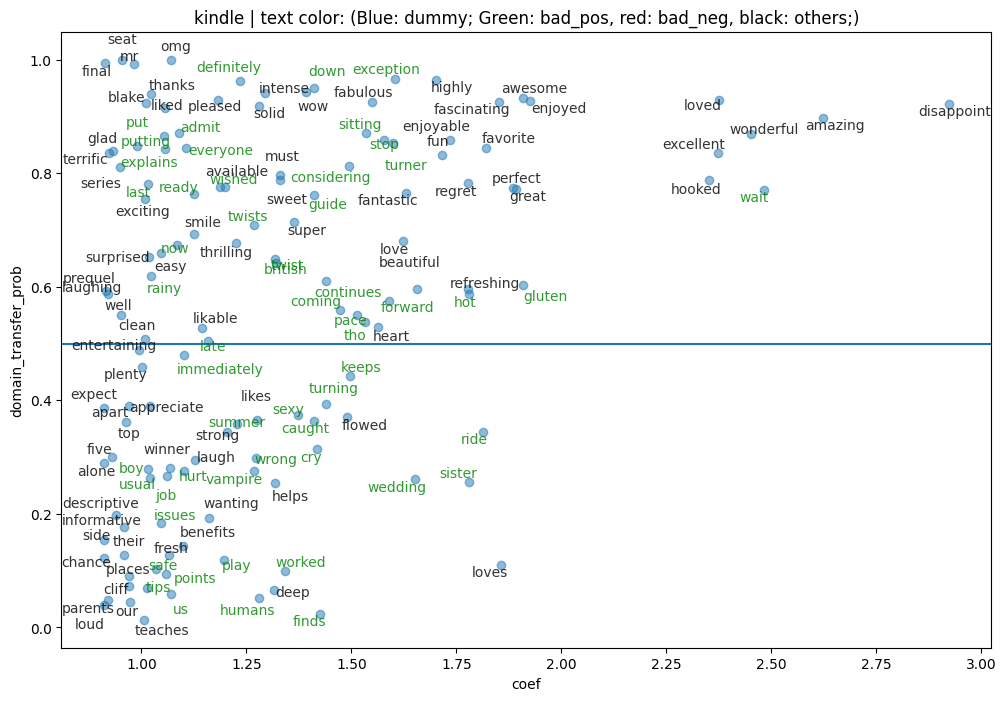

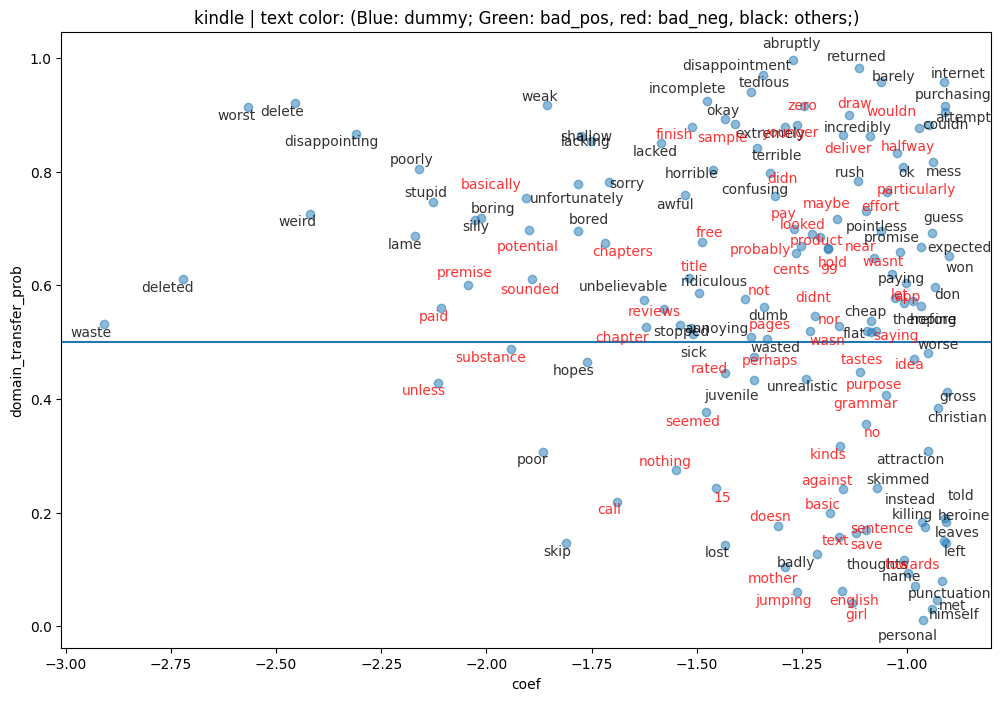

kindle --> imdb
kindle (source), bad VS good terms:  [(-1, 119), (1, 160)]

Feature importance:  [(-0.81, 'ite_weighted_scaled'), (-0.33, 'ite_abs_top_5'), (-0.31, 'diff_max_mean_abs'), (-0.11, 'closest_neg_similarity_scaled'), (-0.1, 'similarity_scaled_max'), (-0.09, 'diff_mean_abs'), (0.0, 'coef'), (0.09, 'diff_mean'), (0.1, 'similarity_scaled_top_5'), (0.11, 'diff_min_mean'), (0.11, 'ite_abs_avg'), (0.12, 'similarity_scaled_std'), (0.13, 'similarity_scaled_avg'), (0.18, 'top_diff_mean'), (0.19, 'ite_x_similarity_scaled'), (0.26, 'closest_pos_similarity_scaled'), (0.26, 'ite_abs_top_5_by_sim'), (0.27, 'diff_max_mean'), (0.46, 'ite_x_similarity_scaled_top_5')]

kindle --> kindle, self-evaluation:

              precision    recall  f1-score   support

          -1       0.57      0.64      0.60       119
           1       0.70      0.64      0.67       160

    accuracy                           0.64       279
   macro avg       0.64      0.64      0.63       279
weighted avg       0

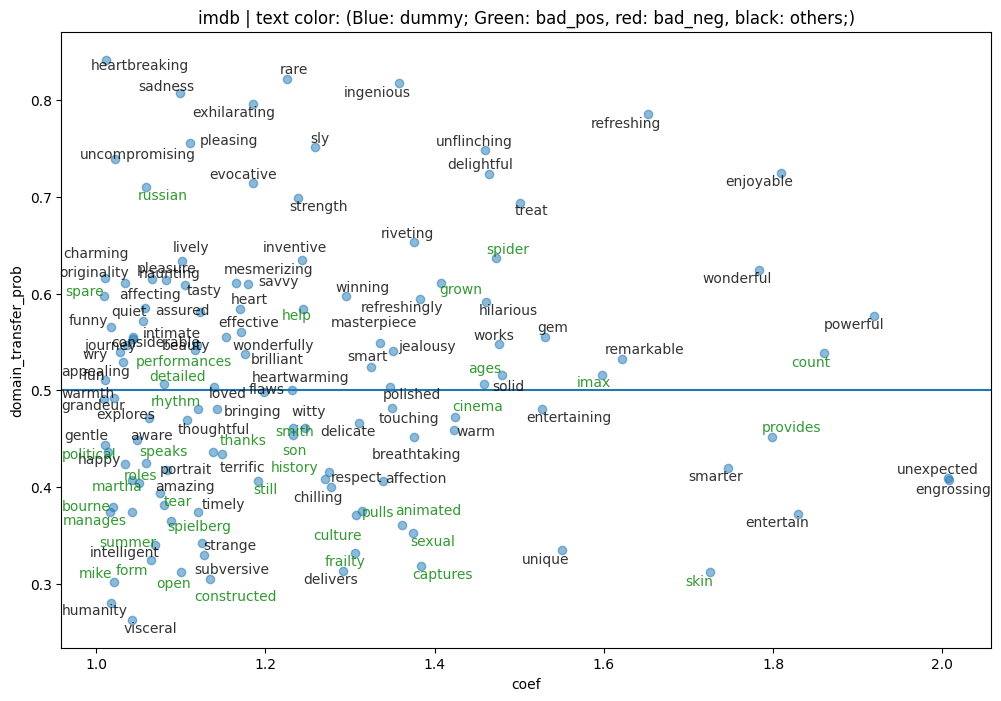

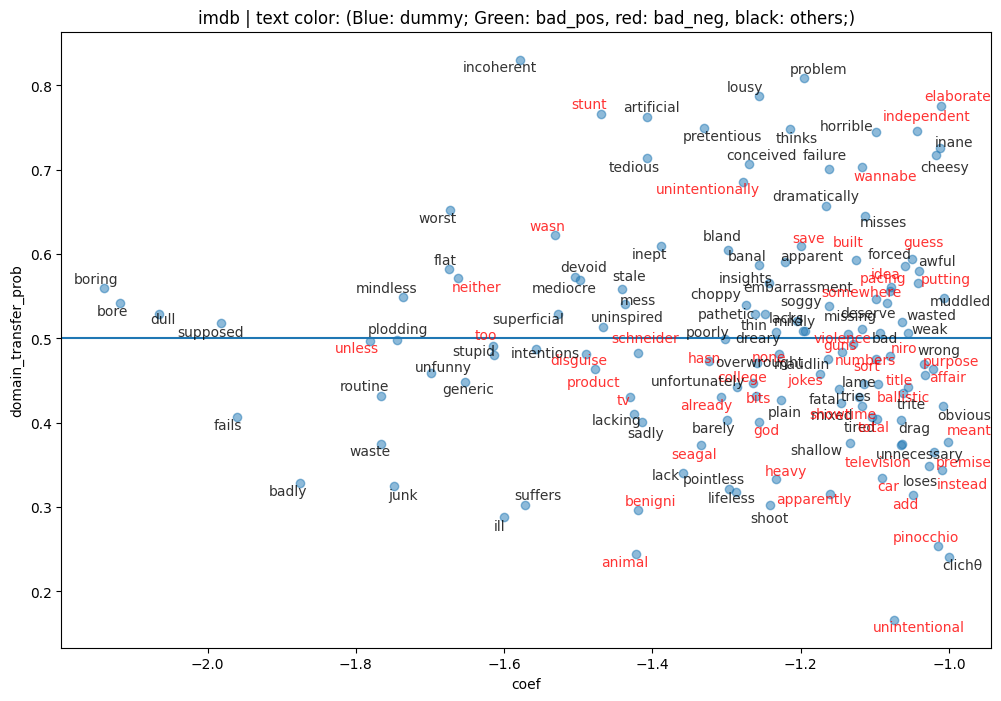

toxic --> toxic_tw
Source: (toxic, 112), target: (toxic_tw, 118), only use pos(toxic) words
toxic (source), bad VS good terms:  [(-1, 38), (1, 74)]

Feature importance:  [(-0.55, 'ite_abs_top_5'), (-0.28, 'ite_abs_avg'), (-0.28, 'similarity_scaled_max'), (-0.09, 'diff_mean_abs'), (-0.07, 'ite_x_similarity_scaled'), (-0.05, 'diff_min_mean'), (-0.02, 'ite_abs_top_5_by_sim'), (0.01, 'diff_max_mean'), (0.02, 'closest_pos_similarity_scaled'), (0.04, 'closest_neg_similarity_scaled'), (0.06, 'ite_x_similarity_scaled_top_5'), (0.09, 'diff_mean'), (0.13, 'diff_max_mean_abs'), (0.23, 'similarity_scaled_avg'), (0.3, 'ite_weighted_scaled'), (0.36, 'top_diff_mean'), (0.58, 'similarity_scaled_std'), (1.1, 'similarity_scaled_top_5'), (1.44, 'coef')]

toxic --> toxic, self-evaluation:

              precision    recall  f1-score   support

          -1       0.65      0.89      0.76        38
           1       0.93      0.76      0.84        74

    accuracy                           0.80       112
 

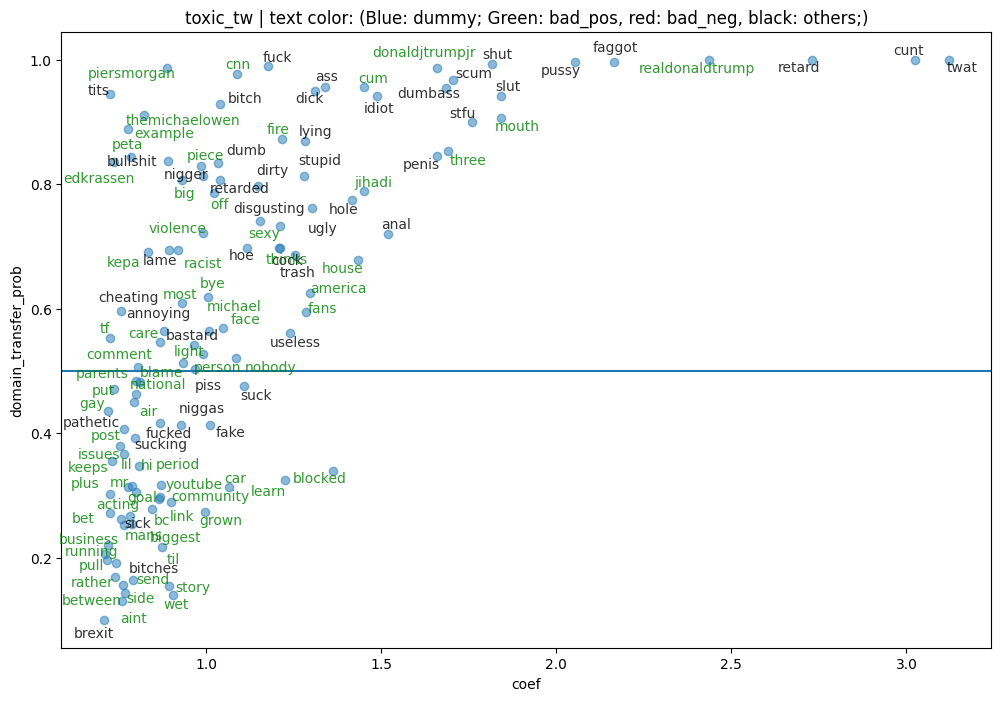

toxic_tw --> toxic
Source: (toxic_tw, 118), target: (toxic, 112), only use pos(toxic) words
toxic_tw (source), bad VS good terms:  [(-1, 72), (1, 46)]

Feature importance:  [(-0.78, 'ite_weighted_scaled'), (-0.37, 'similarity_scaled_avg'), (-0.35, 'diff_min_mean'), (-0.29, 'ite_abs_top_5'), (-0.19, 'similarity_scaled_max'), (-0.19, 'similarity_scaled_top_5'), (-0.08, 'top_diff_mean'), (0.04, 'closest_pos_similarity_scaled'), (0.05, 'diff_max_mean'), (0.17, 'ite_x_similarity_scaled'), (0.17, 'ite_x_similarity_scaled_top_5'), (0.26, 'closest_neg_similarity_scaled'), (0.32, 'diff_max_mean_abs'), (0.32, 'diff_mean'), (0.32, 'diff_mean_abs'), (0.32, 'ite_abs_top_5_by_sim'), (0.33, 'ite_abs_avg'), (0.37, 'similarity_scaled_std'), (0.7, 'coef')]

toxic_tw --> toxic_tw, self-evaluation:

              precision    recall  f1-score   support

          -1       0.79      0.78      0.78        72
           1       0.66      0.67      0.67        46

    accuracy                           0.74  

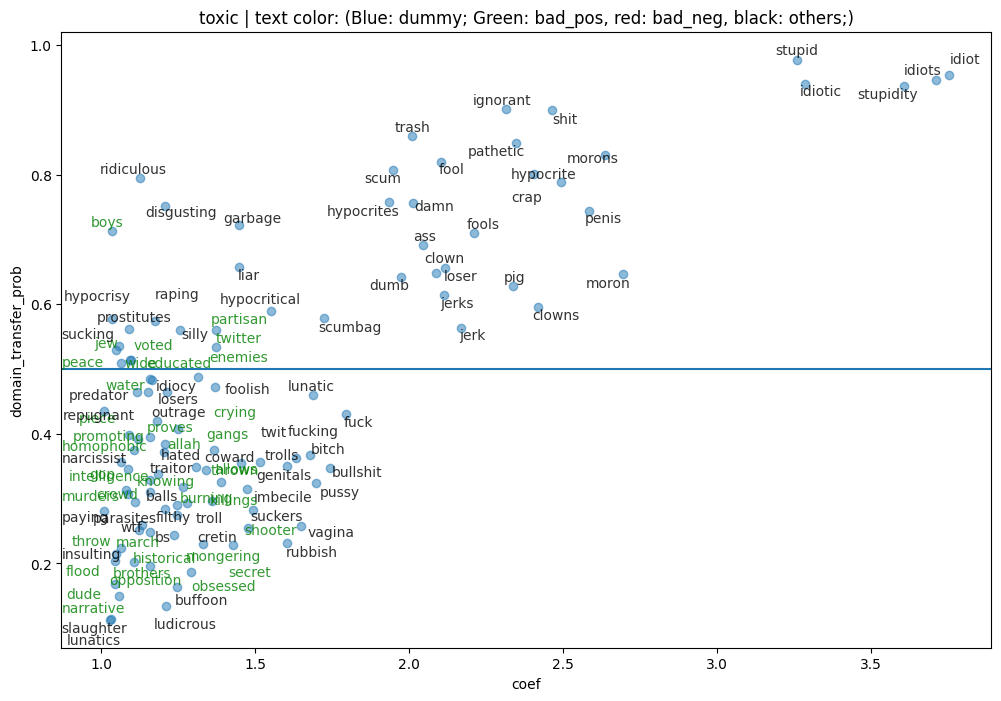

In [172]:
treat_in_domain_result, treat_out_domain_result = run_word_classifier(matchby='treat')

In [115]:
ds_toxic_tw.moniker

'toxic_tw'

In [ ]:
ds_imdb, ds_kindle, ds_toxic, ds_toxic_tw = pickle.load(open('data/datasets_emb.pickle','rb'))
datasets = [ds_imdb, ds_kindle, ds_toxic, ds_toxic_tw]

 
start = time.time()
data_ites_byTreat = []
for ds_data in datasets:
    ds_data.ites = calculate_ites_from_matched_sentences(ds_data, matchby='treat', min_sim=0.01)
    data_ites_byTreat.append(ds_data)
    
end = time.time()
print((end-start)/60)
pickle.dump(data_ites_byTreat, open('data/datasets_treat_match.pickle', 'wb'))

In [17]:
def get_kindle_shorts():
    """
    Kindle book reviews with sentiment labels;
    Pre-processed by:
        Split comments into sentences;
        Filter by keywords;
        Limit sentence length [5,50];
    """
    df = pickle.load(open("data/kindle_short_sents.pickle",'rb'))
    #df = pickle.load(open("data/kindle_unique_sents.pkl",'rb'))
#     df = df.sample(frac=1)
    df.reset_index(drop=True,inplace=True)
        
    return df

In [19]:
def get_dataset_embeddings_kindle_shorts():
    """
    1. Get data from file and construct DataSet object
    2. Get top words, placebo words
    3. Edit sentences and get embeddings for edited sentences:
        Remove top words;
        Remove placebo words;
        Original sentences without edit;
    """
    random.seed(42)
    datasets = []
    get_data_df = get_kindle_shorts()
    coef_thresh = 1.0
    placebo_thresh = 0.1
    moniker = "kindle_short"
    df = get_data_df
    X, y, vec, feats = simple_vectorize(df) # vectorize text
    ds = Dataset(X, y, vec, df, moniker) # construct dataset object
    print('%s dataset, %d instances' % (moniker,len(df)))
    print('Label distribution: %s' % str(Counter(y).items()))
    print('Feature matrix: %s' % str(X.shape))
    ds.top_feature_idx, ds.placebo_feature_idx, ds.coef = get_top_terms(ds, coef_thresh=coef_thresh, placebo_thresh=placebo_thresh, C=1)
    ds.top_features = feats[ds.top_feature_idx]
    ds.placebo_features = feats[ds.placebo_feature_idx]
    print('\n%d top terms: %d pos, %d neg\n' % (len(ds.top_features), len(np.where(ds.coef[ds.top_feature_idx]>0)[0]), len(np.where(ds.coef[ds.top_feature_idx]<0)[0])))
    print('\n%d placebo terms: %d pos, %d neg\n' % (len(ds.placebo_features), len(np.where(ds.coef[ds.placebo_feature_idx]>0)[0]), len(np.where(ds.coef[ds.placebo_feature_idx]<0)[0])))
    ds.topwd_sentObj_list, ds.topwd_sentObj_dict, topwd_sent_idx = remove_wd_from_sentences(X,df.text,df.label,vec,ds.top_features,exclude_sent_idx=[])
    print('Edit %d sentences for top terms\n' % len(ds.topwd_sentObj_list))
    embed_all_sentences(ds.topwd_sentObj_list) 
    ds.placebowd_sentObj_list, ds.placebowd_sentObj_dict, placebowd_sent_idx = remove_wd_from_sentences(X,df.text,df.label,vec,ds.placebo_features,topwd_sent_idx)
    print('Edit %d sentences for placebo terms\n' % len(ds.placebowd_sentObj_list))
    embed_all_sentences(ds.placebowd_sentObj_list) 
    ds.original_sentObj_list = get_original_sentences(df)
    print('%d original sentences')
    embed_all_sentences(ds.original_sentObj_list)    
    datasets.append(ds)
        
    return datasets

In [20]:
start = time.time()
datasets = get_dataset_embeddings_kindle_shorts()
end = time.time()
print((end-start)/60)

(20233, 2384)
new dataset with 20233 records


,text,rating,label
0,This was a very fun story,5,1


kindle_short dataset, 20233 instances
Label distribution: dict_items([(1, 10072), (-1, 10161)])
Feature matrix: (20233, 2384)

Top features for class -1
waste/2.93 deleted/2.82 worst/2.62 delete/2.49 weird/2.47 disappointing/2.29 lame/2.18 poorly/2.17 unless/2.15 paid/2.12 stupid/2.10 silly/2.04 premise/2.02 boring/2.02 substance/1.97 sounded/1.92 basically/1.90 potential/1.87 weak/1.86 poor/1.85 skip/1.84 unfortunately/1.80 sorry/1.78 lacking/1.78 bored/1.78 weeks/1.77 hopes/1.76 shallow/1.75 call/1.69 chapters/1.69 chapter/1.61 finish/1.60 religious/1.60 nothing/1.60 lacked/1.60 unbelievable/1.58 reviews/1.56 free/1.55 annoying/1.53 title/1.53 awful/1.52 stopped/1.52 sick/1.52 blurb/1.49 incomplete/1.49 okay/1.48 rated/1.48 ridiculous/1.48 impress/1.45 horrible/1.44 15/1.44 seemed/1.44 print/1.43 sample/1.42 not/1.41 lost/1.40 tedious/1.39 perhaps/1.39 pages/1.38 disappointment/1.35 dumb/1.35 juvenile/1.34 wasted/1.34 didn/1.33 mother/1.33 extremely/1.32 terrible/1.32 luck/1.31 confu

loading file vocab.txt from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/vocab.txt
loading file added_tokens.json from cache at None
loading file special_tokens_map.json from cache at None
loading file tokenizer_config.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer_config.json
loading file tokenizer.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer.json
loading file chat_template.jinja from cache at None
loading configuration file config.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/config.json
Model config BertConfig {
  "_name_or_path": "bert-base-uncased",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.

  0%|          | 0/25368 [00:00<?, ?it/s]

...

loading file vocab.txt from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/vocab.txt
loading file added_tokens.json from cache at None
loading file special_tokens_map.json from cache at None
loading file tokenizer_config.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer_config.json
loading file tokenizer.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer.json
loading file chat_template.jinja from cache at None
loading configuration file config.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/config.json
Model config BertConfig {
  "_name_or_path": "bert-base-uncased",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.

%d original sentences


loading configuration file config.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/config.json
Model config BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_attentions": true,
  "output_hidden_states": true,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.49.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

loading weights file model.safetensors from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd1

  0%|          | 0/20233 [00:00<?, ?it/s]

37.58161996205648


In [22]:
kindle_shorts= datasets[0]

In [24]:
kindle_shorts.df.shape, len(kindle_shorts.top_features)


((20233, 4), 269)

In [25]:
pickle.dump(datasets, open('data/kindle_shorts_emb.pickle','wb'))


In [31]:
def get_toxic_shorts():
    """
    Kindle book reviews with sentiment labels;
    Pre-processed by:
        Split comments into sentences;
        Filter by keywords;
        Limit sentence length [5,50];
    """
    df = pickle.load(open("data/toxic_short_sents.pickle",'rb'))
    #df = pickle.load(open("data/kindle_unique_sents.pkl",'rb'))
#     df = df.sample(frac=1)
    df.reset_index(drop=True,inplace=True)
        
    return df

In [32]:
def get_dataset_embeddings_toxic_shorts():
    """
    1. Get data from file and construct DataSet object
    2. Get top words, placebo words
    3. Edit sentences and get embeddings for edited sentences:
        Remove top words;
        Remove placebo words;
        Original sentences without edit;
    """
    random.seed(42)
    datasets = []
    get_data_df = get_toxic_shorts()
    coef_thresh = 1.0
    placebo_thresh = 0.1
    moniker = "toxic_short"
    df = get_data_df
    X, y, vec, feats = simple_vectorize(df) # vectorize text
    ds = Dataset(X, y, vec, df, moniker) # construct dataset object
    print('%s dataset, %d instances' % (moniker,len(df)))
    print('Label distribution: %s' % str(Counter(y).items()))
    print('Feature matrix: %s' % str(X.shape))
    ds.top_feature_idx, ds.placebo_feature_idx, ds.coef = get_top_terms(ds, coef_thresh=coef_thresh, placebo_thresh=placebo_thresh, C=1)
    ds.top_features = feats[ds.top_feature_idx]
    ds.placebo_features = feats[ds.placebo_feature_idx]
    print('\n%d top terms: %d pos, %d neg\n' % (len(ds.top_features), len(np.where(ds.coef[ds.top_feature_idx]>0)[0]), len(np.where(ds.coef[ds.top_feature_idx]<0)[0])))
    print('\n%d placebo terms: %d pos, %d neg\n' % (len(ds.placebo_features), len(np.where(ds.coef[ds.placebo_feature_idx]>0)[0]), len(np.where(ds.coef[ds.placebo_feature_idx]<0)[0])))
    ds.topwd_sentObj_list, ds.topwd_sentObj_dict, topwd_sent_idx = remove_wd_from_sentences(X,df.text,df.label,vec,ds.top_features,exclude_sent_idx=[])
    print('Edit %d sentences for top terms\n' % len(ds.topwd_sentObj_list))
    embed_all_sentences(ds.topwd_sentObj_list) 
    ds.placebowd_sentObj_list, ds.placebowd_sentObj_dict, placebowd_sent_idx = remove_wd_from_sentences(X,df.text,df.label,vec,ds.placebo_features,topwd_sent_idx)
    print('Edit %d sentences for placebo terms\n' % len(ds.placebowd_sentObj_list))
    embed_all_sentences(ds.placebowd_sentObj_list) 
    ds.original_sentObj_list = get_original_sentences(df)
    print('%d original sentences')
    embed_all_sentences(ds.original_sentObj_list)    
    datasets.append(ds)
        
    return datasets

In [33]:
start = time.time()
datasets = get_dataset_embeddings_kindle_shorts()
end = time.time()
print((end-start)/60)

(15216, 4628)
new dataset with 15216 records


,target,text,label,id
0,0.428571,"Zuma is nothing if we compare him with ramaphosa and rupert, black people struggling till now in their own own country and rupert and wmc are busy in looting from our country",-1,0


kindle_short dataset, 15216 instances
Label distribution: dict_items([(-1, 7608), (1, 7608)])
Feature matrix: (15216, 4628)

Top features for class -1
india/2.12 103/1.96 closer/1.96 meaningful/1.95 reduced/1.93 reform/1.88 items/1.74 exceptions/1.74 niqab/1.70 harper/1.62 loved/1.59 shootings/1.55 reported/1.53 bank/1.53 legally/1.50 ndp/1.48 predominantly/1.48 ted/1.45 july/1.44 demonstrates/1.44 lived/1.40 gain/1.39 thus/1.38 border/1.38 discussions/1.38 pressure/1.37 clever/1.37 reporting/1.36 thomas/1.35 technology/1.34 william/1.33 colorado/1.33 harvey/1.33 recognize/1.32 eye/1.32 prosecuted/1.32 original/1.31 mail/1.30 blackberry/1.30 understanding/1.27 honored/1.27 supreme/1.27 accusations/1.27 healthcare/1.26 exposed/1.26 25/1.26 card/1.25 oregon/1.25 arrested/1.24 unfortunately/1.24 internal/1.23 doctor/1.23 bravery/1.22 46/1.22 figures/1.21 hunting/1.21 replaced/1.21 percentage/1.20 strikes/1.20 branded/1.20 bears/1.19 negative/1.19 clerics/1.19 financial/1.19 allied/1.19 dr

loading file vocab.txt from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/vocab.txt
loading file added_tokens.json from cache at None
loading file special_tokens_map.json from cache at None
loading file tokenizer_config.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer_config.json
loading file tokenizer.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer.json
loading file chat_template.jinja from cache at None
loading configuration file config.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/config.json
Model config BertConfig {
  "_name_or_path": "bert-base-uncased",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.

  0%|          | 0/8230 [00:00<?, ?it/s]

...

  0%|          | 0/29673 [00:00<?, ?it/s]

%d original sentences


loading file vocab.txt from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/vocab.txt
loading file added_tokens.json from cache at None
loading file special_tokens_map.json from cache at None
loading file tokenizer_config.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer_config.json
loading file tokenizer.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer.json
loading file chat_template.jinja from cache at None
loading configuration file config.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/config.json
Model config BertConfig {
  "_name_or_path": "bert-base-uncased",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.

  0%|          | 0/15216 [00:00<?, ?it/s]

30.685365768273673


In [34]:
pickle.dump(datasets, open('data/toxic_shorts_emb.pickle','wb'))


In [35]:
ds_toxic_short = datasets[0]

In [36]:
len(set(ds_imdb.top_features).intersection(set(kindle_shorts.top_features)))


43

In [37]:
ds_toxic_short.df.shape, len(ds_toxic_short.top_features)


((15216, 5), 320)

In [68]:
dt = pickle.load(open('data/kindle_shorts_emb.pickle','rb'))
datasets = [dt[0]]

 
start = time.time()
data_ites_byTreat = []
for ds_data in datasets:
    ds_data.ites = calculate_ites_from_matched_sentences(ds_data, matchby='treat', min_sim=0.01)
    data_ites_byTreat.append(ds_data)
    
end = time.time()
print((end-start)/60)
pickle.dump(data_ites_byTreat, open('data/kindle_shorts_treat_match.pickle','wb'))

  0%|          | 0/25368 [00:00<?, ?it/s]

119.88713773488999


In [69]:
dt = pickle.load(open('data/toxic_shorts_emb.pickle','rb'))
datasets = [dt[0]]

 
start = time.time()
data_ites_byTreat = []
for ds_data in datasets:
    ds_data.ites = calculate_ites_from_matched_sentences(ds_data, matchby='treat', min_sim=0.01)
    data_ites_byTreat.append(ds_data)
    
end = time.time()
print((end-start)/60)
pickle.dump(data_ites_byTreat, open('data/toxic_shorts_treat_match.pickle','wb'))


  0%|          | 0/8230 [00:00<?, ?it/s]

4.882577383518219


In [173]:
ds_data = pickle.load(open('data/datasets_with_term_prob.pickle','rb'))
type(ds_data)

list

In [174]:
imdb_good_pos = ds_data[1].term_df[(ds_data[1].term_df.label==1) & (ds_data[1].term_df.coef>0)]
imdb_good_neg = ds_data[1].term_df[(ds_data[1].term_df.label==1) & (ds_data[1].term_df.coef<0)]
imdb_bad_pos = ds_data[1].term_df[(ds_data[1].term_df.label==-1) & (ds_data[1].term_df.coef>0)]
imdb_bad_neg = ds_data[1].term_df[(ds_data[1].term_df.label==-1) & (ds_data[1].term_df.coef<0)]
imdb_good_pos.shape, imdb_good_neg.shape, imdb_bad_pos.shape, imdb_bad_neg.shape

((88, 24), (85, 24), (38, 24), (51, 24))

In [175]:
imdb_good_pos.sort_values(by=['coef'],ascending=False).head(20)


,term,ite_abs_avg,ite_abs_top_5,similarity_scaled_avg,similarity_scaled_top_5,similarity_scaled_std,similarity_scaled_max,closest_pos_similarity_scaled,closest_neg_similarity_scaled,ite_abs_top_5_by_sim,...,diff_mean_abs,diff_mean,top_diff_mean,diff_max_mean_abs,diff_max_mean,diff_min_mean,coef,label,cv_prob,domain_transfer_prob
60,engrossing,0.424242,2.0,0.588532,0.709383,0.076124,0.804833,0.804833,0.647729,0.0,...,0.001795,-0.001795,0.365265,0.460384,0.401349,-0.408149,2.008,1,0.788538,0.407142
235,unexpected,0.800000,2.0,0.563203,0.673703,0.093447,0.745566,0.745566,0.711702,0.8,...,0.002263,-0.002263,0.574328,0.449682,0.380301,-0.386594,2.007,1,0.432621,0.409116
160,powerful,0.784314,2.0,0.606523,0.782517,0.093539,0.847727,0.847727,0.766965,0.4,...,0.001468,-0.001468,0.462300,0.484430,0.427621,-0.430348,1.919,1,0.811274,0.577231
62,entertain,0.666667,1.6,0.570983,0.615022,0.047253,0.659593,0.631273,0.659593,0.8,...,0.001614,-0.001614,0.278429,0.387579,0.314670,-0.320537,1.829,1,0.246776,0.372419
61,enjoyable,0.426230,2.0,0.629180,0.874220,0.109932,0.999999,0.999999,0.999998,0.4,...,0.001314,-0.001314,0.427091,0.489879,0.434996,-0.436665,1.809,1,0.953936,0.725072
256,wonderful,0.647059,2.0,0.615557,0.746059,0.079050,0.760613,0.760613,0.757085,1.2,...,0.001306,-0.001306,0.445568,0.451231,0.390719,-0.394596,1.783,1,0.734995,0.624503
193,smarter,1.000000,2.0,0.569536,0.625916,0.074249,0.678243,0.678243,0.643967,0.8,...,0.001708,-0.001708,0.510566,0.387968,0.319780,-0.316717,1.747,1,0.450053,0.419154
171,refreshing,0.956522,2.0,0.686389,0.903217,0.143198,1.000000,0.824747,1.000000,1.6,...,0.001157,-0.001157,0.314398,0.394515,0.332861,-0.335345,1.652,1,0.998652,0.785594
173,remarkable,0.303030,2.0,0.576881,0.693059,0.079959,0.718364,0.715149,0.718364,0.8,...,0.001374,-0.001374,0.533362,0.461189,0.403754,-0.402046,1.622,1,0.278729,0.532457
242,unique,0.260870,2.0,0.567705,0.648393,0.071001,0.681846,0.681846,0.623000,0.0,...,0.001747,-0.001747,0.483108,0.433200,0.370671,-0.375258,1.550,1,0.312317,0.334820


In [176]:
bad_pos = ['provides','imax','spider','cinema','sexual','tear','detailed','spielberg','russian','roles']
bad_neg = ['animal', 'tv', 'seagal', 'god', 'heavy', 'jokes','guns','violence','disguise','unintentionally']
good_pos = ['unexpected', 'engrossing','entertain','wonderful','smarter','unique','gem','treat','works','solid']
good_neg = ['boring','bore','dull','fails','routine','waste','mindless','unfunny','flat','generic']


In [177]:
from spurious_words import imdb_bad_pos, imdb_bad_neg, kindle_bad_pos, kindle_bad_neg, toxic_bad_pos, toxic_tw_bad_pos


In [178]:
len(set(imdb_bad_pos + imdb_bad_neg)), len(set(kindle_bad_pos + kindle_bad_neg)), len(set(imdb_bad_pos + imdb_bad_neg).intersection(set(kindle_bad_pos + kindle_bad_neg)))


(145, 154, 12)

In [179]:
len(set(toxic_bad_pos)), len(set(toxic_tw_bad_pos)), len(set(toxic_bad_pos).intersection(set(toxic_tw_bad_pos)))


(72, 139, 3)

In [180]:
len(toxic_tw_bad_pos)


139

In [181]:
import copy, io, time
from io import BytesIO
from itertools import combinations, cycle, product
from IPython.display import display
import math
import matplotlib.pyplot as plt
%matplotlib inline

import pickle, tarfile, random, re, requests
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', -1)

from tqdm.notebook import tqdm

import sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, precision_recall_fscore_support

import warnings
warnings.filterwarnings("ignore")

In [183]:
def load_data_with_term_prob():
    """
    load data that each term has a predicted probability of being genuine / (1-spurious);
    ds_data:
        - dataframe of [X, y, ..., ites, term_df]
        - ites is dataframe of matched sentence pairs: ['term','sentence_id','treat_obj','control_obj','similarity','difference','ite']
        - term_df is dataframe of feature representations (calculated from ites) for each term (e.g., ite features, coef, predicted_prob);
    
    use_prob: OOB (domain transfer), 5cv (same domain)
    Load data from file:
        ds.BAD_POS
        ds.BAD_NEG
        ds.term_df.predicted_prob
    """
    random.seed(42)
    
    path = 'data/' #V_6_shortSents

    ds_kindle, ds_imdb, ds_toxic_tw, ds_toxic = pickle.load(open(path+'datasets_with_term_prob.pickle','rb'))
#     ds_kindle_s2t, ds_imdb_s2t, ds_toxic_tw_s2t, ds_toxic_s2t = pickle.load(open(path+'datasets_src2tar_OOB_prob.pickle','rb'))

    return ds_kindle, ds_imdb, ds_toxic_tw, ds_toxic

In [184]:
ds_kindle, ds_imdb, ds_toxic_tw, ds_toxic = load_data_with_term_prob()


In [185]:
ds_toxic_tw.moniker


'toxic_tw'

In [186]:
def iter_options():
    # iterate over combinations of options.
    for use_probs in product(['oracle','feature_selection','domain_transfer','random'], [True, False]):
            if(not (use_probs=='random' and do_weight)):
                yield (use_probs, do_weight)
                        
def line_styles():
    """
    different line markers
    """
    markers = ['<', '+', '*',  'v', 's', 'D', 'P', 'o', '.','<', '>', '1', '+', 'X',
               '^', 's', '*', 'D', 'P', '.', 'v', '<', '>', '1',  'X']
    lines = ['-', '--', '-.', ':'] * 6
    
    return cycle(['%s%s' % (m, l) for l, m in zip(lines, markers)])

In [195]:
def sample_from_training_data(ds_data, train_idx, test_idx, test_majority_idx, test_minority_idx, axs):
    """
    In training set, sample n_majority = n_minority;
    Balance the effect of majority and minority groups in training set;
    Fit classifier on balanced training set and check performance on evaluation groups.
    """
    bad_term_stats, majority_idx, minority_idx = get_term_stats(ds_data,train_idx)
    
    smp_majority_idx = list(random.sample(majority_idx, len(minority_idx)))
    smp_train_idx = list(set(train_idx) - (set(majority_idx) - set(smp_majority_idx)))
    print("Train data distribution after sample majority group:",Counter(ds_data.y[smp_train_idx]))
    
    clf = LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=1000)
    clf.fit(ds_data.X[smp_train_idx], ds_data.y[smp_train_idx])
    
    group_score = {}
    for group, gp_idx in zip(['majority','minority','random'],[test_majority_idx, test_minority_idx, test_idx]):
        if(ds_data.moniker in ['Toxic comment','Toxic tweet']):
            group_score[group] = accuracy_score(ds_data.y[gp_idx],clf.predict(ds_data.X[gp_idx]))
        else:
            group_score[group] = roc_auc_score(ds_data.y[gp_idx],clf.predict_proba(ds_data.X[gp_idx]))
   
    # Horizontal line indicating the performance when training data is balanced 
    for i,group in enumerate(['majority','minority','random']):
        axs[i].axhline(group_score[group], alpha=0.8, linestyle='--')

In [188]:
def get_term_stats(df, data_idx):
    """
    Collect information about how often each word appears in majority and minority category.
    df: dataframe of each dataset
    data_idx: docs to sample from;
    
    For bad terms, sample the evaluation groups:
        Majority groups: (bad_pos, pos), (bad_neg, neg) 
        Minority groups: (bad_pos, neg), (bad_neg, pos)
    
    return: bad_term_stats, [term, n_docs, majority_idx, minority_idx, n_majority, n_minority, prob]
    """
    pos_idx = set(np.where(df.y==1)[0]).intersection(set(data_idx))
    neg_idx = set(np.where(df.y==-1)[0]).intersection(set(data_idx))
    
    bad_term_stats = []
    all_majority = set() # all majority docs regarding top terms
    all_minority = set() # all minority docs regarding top terms
    
    for ri, row_term in df.term_df.iterrows():
        if row_term['label'] == -1: # bad term
            term_i = df.vec.vocabulary_[row_term['term']] 
            term_docs = set(df.X[:,term_i].nonzero()[0])
            
            if row_term['coef'] < 0: # bad_neg words
                maj_idx = neg_idx & term_docs
                min_idx = pos_idx & term_docs
            else:                   # bad_pos_words
                maj_idx = pos_idx & term_docs
                min_idx = neg_idx & term_docs
                
            all_majority.update(maj_idx)
            all_minority.update(min_idx)
            
            bad_term_stats.append({
                'term': row_term['term'],
                'n_docs': len(term_docs),
                'majority_idx': maj_idx,
                'minority_idx': min_idx,
                'n_majority': len(maj_idx),
                'n_minority': len(min_idx),
                'cv_prob': row_term['cv_prob'],
                'domain_transfer_prob': row_term['domain_transfer_prob'],
            })
                
    return pd.DataFrame(bad_term_stats), all_majority, all_minority


def smp_equal_docs_per_term(ds_data, bad_term_stats, prohibited_idx, group, smp_size=2):
    """
    bad_term_stats: [term, n_docs, majority_idx, minority_idx, n_majority, n_minority, prob]
    group: majority / minority;
    
    Sample equal number of docs for each term;
    Term with lowest frequency has highest priority;
    
    smp_size:
        if > 0: specified smp_size
        elif < 0: calculated smp_size
        
    Return: sampled doc idx, dict[term] = sampled docs idx;
    """
    random.seed(42)
    
    if(smp_size == 0):
        smp_size = max(2, bad_term_stats['n_%s' % group].min()) # try to get at least this many samples per word.
        print("Sample size for %s: %d" % (group,smp_size))
    
    sampled_bad_terms = []
    sampled_indices = set() # docs that are being sampled
    
    # for each word
    for i, term_stat in bad_term_stats.sort_values('n_%s' % group).iterrows():
        if term_stat['n_%s' % group] > 0: # if have more than 0 docs in this group
            doc_idx = list(term_stat['%s_idx' % group])
            available_doc_idx = set(doc_idx) - set(sampled_indices) - set(prohibited_idx)
            smp_doc_idx = random.sample(available_doc_idx, min(smp_size,len(available_doc_idx)))
            sampled_indices.update(smp_doc_idx)
            sampled_bad_terms.append({'term':term_stat['term'],'%s_smp' % group :smp_doc_idx})
            
        else:
            continue
            
    return list(sampled_indices), pd.DataFrame(sampled_bad_terms)


def get_train_test_set(ds_data,smp_method='random'):
    """
    smp_method == random:
        1. random split 60% train, 40% test;
        2. sample majority and minority groups from test set;
        3. from majority and minority groups, sample equal number of docs for each term (specified by term_smp_size);
    smp_method != random:
        1. sample majority and minority groups from whole data set;
        2. from majority and minority groups, sample equal number of docs for each term (smp_size as min(2,min_docs per term));
        3. remaining data as training set;
    
    Return: train set, majority test set, minority test set;
    """
    if (smp_method == 'random'):
        # 1. random split
        train_idx, test_idx = train_test_split(np.arange(len(ds_data.y)), test_size=0.4, shuffle=True, random_state=42)
        # 2 get term stats in test set
        bad_term_stats, test_majority_idx, test_minority_idx = get_term_stats(ds_data, test_idx)
        # 3 sample equal number of docs per term from majority and minority
        prohibited_idx = test_majority_idx & test_minority_idx 
        minority_smp_idx, min_bad_terms = smp_equal_docs_per_term(ds_data,bad_term_stats,prohibited_idx,group='minority',smp_size=2)
        majority_smp_idx, maj_bad_terms = smp_equal_docs_per_term(ds_data,bad_term_stats,prohibited_idx,group='majority',smp_size=2)
        
    else:
        # 1 get term stats in whole data set
        bad_term_stats, all_majority_idx, all_minority_idx = get_term_stats(ds_data, np.arange(len(ds_data.y)))
        # 2 sample equal number of docs per term from majority and minority
        prohibited_idx = all_majority_idx & all_minority_idx 
        minority_smp_idx, min_bad_terms = smp_equal_docs_per_term(ds_data,bad_term_stats,prohibited_idx,group='minority',smp_size=0)
        majority_smp_idx, maj_bad_terms = smp_equal_docs_per_term(ds_data,bad_term_stats,prohibited_idx,group='majority',smp_size=0)
        # 3 remaining docs are train data
        train_idx = set(np.arange(len(ds_data.y))) - (set(majority_smp_idx) | set(minority_smp_idx))
    
    print('Sampled %d train instances; \ntest indices: (%d majority docs, %d terms), (%d minority docs, %d terms), intersection=%d' % 
          (len(train_idx), len(majority_smp_idx), maj_bad_terms.shape[0], 
           len(minority_smp_idx), min_bad_terms.shape[0],
           len(set(majority_smp_idx) & set(minority_smp_idx))))
    
    return list(train_idx), majority_smp_idx, minority_smp_idx, maj_bad_terms, min_bad_terms


In [196]:
def sort_terms_by_Prob(ds_data, feature_order):
    """
    sort terms by p(correct correlation) in ascending order
    """
    
    if (feature_order == 'feature_selection' or feature_order == 'feature_weighted'): # sort all important terms in probability increasing order
        terms_in_order = sorted(list(zip(ds_data.term_df.cv_prob, ds_data.term_df.term)))
        
    elif(feature_order == 'oracle'): # use_labels, randomly sort bad terms, intersection with term_df
        terms = list(set(ds_data.ALL_BAD.copy()).intersection(set(ds_data.term_df.term)))
        random.shuffle(terms)
        terms_in_order = list(zip([.1] * len(terms), terms))

    elif(feature_order == 'domain_transfer'):
        terms_in_order = sorted(list(zip(ds_data.term_df.domain_transfer_prob, ds_data.term_df.term)))
        
    elif (feature_order == 'random'): # randomly sort terms in ds_data.term_df
        terms_in_order = list(zip([.1] * len(ds_data.term_df.term), ds_data.term_df.term))
        random.shuffle(terms_in_order)
    else:
        print('Feature order not defined.')
    
    return terms_in_order

def remove_feats(X, indices):
    """
    set specified column in X to 0 use diagonal matrix multiplication
    """
    vals = np.ones(X.shape[1])
    vals[indices] = 0
    
    matrix = lil_matrix((len(vals), len(vals)))
    matrix.setdiag(vals)
    return X * matrix

def feature_selection(ds_data, train_idx, test_idx, feature_order='oracle',word_counts=None,verbose=False):
    """
    Sort terms in order (according to different methods):
        - oracle: sort human labeled bad terms in random order;
        - feature_selection: sort terms in probability(5-cv prediction) ascending order; 
        - domain_transfer: sort terms in probability(domain transfer prediction) ascending order; 
        - random: randomly sort good+bad terms;
        
    Increasingly remove/re-weight topn terms;
    """
    
    clf = LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=1000)
    clf.fit(ds_data.X[train_idx], ds_data.y[train_idx])
    
    terms_in_order = sort_terms_by_Prob(ds_data, feature_order)
    
    # only consider removing terms that actually appear in the specific test set.
    if word_counts is not None:
        terms_in_order = [t for t in terms_in_order if word_counts[ds_data.vec.vocabulary_[t[1]]]>0]
    
    all_coef = clf.coef_[0].copy()    
    score = []
    
    for torem in range(0, len(terms_in_order)+1): # tqdm(), increasingly remove/reweight terms
        try:
            terms_torem = terms_in_order[:torem]
            term_idx = np.array([ds_data.vec.vocabulary_[t[1]] for t in terms_torem])
            term_probs = np.array([t[0] for t in terms_torem])

            if len(term_idx) > 0: # more than 0 terms to change
                if feature_order == 'feature_weighted': 
                    # weight coef by proba, rather than removing.
                    factor = np.ones(len(all_coef))
                    factor[term_idx] = term_probs
                    clf.coef_[0] = all_coef.copy() * factor
                else: 
                    # feature selection by: oracle, p_spurious, random
                    clf.coef_[0][term_idx] = 0
                    # optionally retrain after removing feats.
                    # if retrain:
                         # interestingly, this usually hurts performance quite a bit on random sample.
                         # reason? classifier learns other terms as substitutes for the terms we removed,
                         # plus more overfitting...
                         # clf.fit(remove_feats(ds_data.X[train_idx], term_idx), ds_data.y[train_idx])
            # else:
                # print("Terms not in training data")

            pred_lb = clf.predict(ds_data.X[test_idx])
            pred_prob = clf.predict_proba(ds_data.X[test_idx])[:,1]
        
        except Exception as e:
            print('EXCEPTION %s' % str(e))
            traceback.print_exc()
            continue
            
        
        if(len(Counter(ds_data.y[test_idx]).keys())==1): # data only contain one class (toxic_wiki, toxic_tw)
            score.append(accuracy_score(ds_data.y[test_idx], pred_lb))
        else:
            score.append(roc_auc_score(ds_data.y[test_idx], pred_prob))
            
        if verbose and len(terms_torem) > 0:
            print('removed (%s,%.3f) score=%.3f' % (terms_torem[-1][1], terms_torem[-1][0],score[-1]))
        
    return score

In [190]:
def feature_selection_for_doc_classification(ds_data,axs_list,sample_by='random'):
    """
    ds_data: with p(genuine|term) by same domain cross validation and domain transfer;
    
    sample_by: 
        - random: random split first, and then sample minority and majority
        - priority: sample minority and majority first
        
    Document classification using different feature selection methods:
    - Perform feature selection on each evaluation group:
        - majority
        - minority
        - test set
      
    - feature selection strategies:
        - oracle
        - rank by probability from 5-cv: feature_selection, feature_weighted
        - rank by probability from domain_transfer
        - randomly rank good+bad terms
    """
    print("\n",ds_data.moniker)
    random.seed(42)
    
    train_idx, majority_idx, minority_idx, maj_bad_terms, min_bad_terms = get_train_test_set(ds_data,sample_by)
    test_idx = minority_idx + majority_idx
    
    print("Train distribution:",Counter(ds_data.y[train_idx]))
    print("Test distribution:",Counter(ds_data.y[test_idx]))
    print("Majority distribution:",Counter(ds_data.y[majority_idx]))
    print("Minority distribution:",Counter(ds_data.y[minority_idx]))
    
    
    # downsampling training to ensure majority = minority
#     sample_from_training_data(ds_data, train_idx, test_idx, majority_idx, minority_idx, axs_list) #, p_axs
    
    # list of word frequency [0,1,0,...]
    word_counts = ds_data.X[test_idx].sum(axis=0).A1    
    linecycler = line_styles()
    
    for mi,method in enumerate(['oracle','feature_selection','feature_weighted','domain_transfer','random','lexicon']):
        
        if(method != 'lexicon'):
            marker = next(linecycler) # each method corresponds to one line style

            # majority
            scores_for_majority = feature_selection(ds_data, train_idx, majority_idx, method, word_counts) # bad_terms=list(maj_bad_terms['term'].values
            axs_list[0].plot(np.arange(len(scores_for_majority)), scores_for_majority, marker, markersize=12,
                                                           linewidth=2, alpha=.6, label=method, markevery=10) 

            # minority
            scores_for_minority = feature_selection(ds_data, train_idx, minority_idx, method, word_counts)
            axs_list[1].plot(np.arange(len(scores_for_minority)), scores_for_minority, marker, markersize=12,
                                                           linewidth=2, alpha=.6, label=method, markevery=10)

            # test
            scores_for_test = feature_selection(ds_data, train_idx, test_idx, method, word_counts)
            axs_list[2].plot(np.arange(len(scores_for_test)), scores_for_test, marker, markersize=12,
                                                           linewidth=2, alpha=.6, label=method, markevery=10)
        
        else:
            print("Majority:", feature_selection_by_lexicon(ds_data, train_idx, majority_idx, method, word_counts))
            print("Minority:", feature_selection_by_lexicon(ds_data, train_idx, minority_idx, method, word_counts))
            print('Test:',feature_selection_by_lexicon(ds_data, train_idx, test_idx, method, word_counts))


In [193]:
def evaluate_feature_selection(task='sentiment',sample_by='random'):
    """
    task == sentiment | toxic
    sample_by == random | priority
    """
    path = 'data/'

    [ds_kindle, ds_imdb, ds_toxic_tw, ds_toxic] = pickle.load(open(path+'datasets_with_term_prob.pickle','rb'))
    
    ds_imdb.moniker = 'IMDB'
    ds_kindle.moniker = 'Kindle'
    ds_toxic.moniker = 'Toxic comment'
    ds_toxic_tw.moniker = 'Toxic tweet'
        
    if task == 'sentiment':
        datas = [ds_imdb, ds_kindle]
        score = 'AUC'
        print()
    elif task == 'toxic':
        datas = [ds_toxic, ds_toxic_tw]
        score = 'Accuracy'
    
    fig, axs = plt.subplots(2,3,figsize=(18,14),sharex=False,sharey='row')
    axs = axs.flatten()
    p_i = 0
    
    for ds_data in datas:
        feature_selection_for_doc_classification(ds_data,[axs[p_i+0],axs[p_i+1],axs[p_i+2]],sample_by)
        
        axs[p_i+0].set_ylabel(ds_data.moniker+" (%s)" % score, fontsize=25)
        axs[p_i+0].yaxis.set_tick_params(labelsize=25)        
        p_i += 3
        
    
    fig.suptitle('Number of features removed', fontsize=26, x=0.5, y=.02, va='bottom')    

    axs[0].set_title("Majority", fontsize=30)
    axs[1].set_title("Minority", fontsize=30)
    axs[2].set_title("All",fontsize=30)
    
    plt.subplots_adjust(wspace=0.05, hspace=.2)
    
    # reference: https://jakevdp.github.io/PythonDataScienceHandbook/04.10-customizing-ticks.html
    axs[0].yaxis.set_major_locator(plt.MaxNLocator(5))
    axs[3].yaxis.set_major_locator(plt.MaxNLocator(5))
    
    for a in axs:
        a.xaxis.set_tick_params(labelsize=25, rotation=90)
        a.xaxis.set_major_locator(plt.MaxNLocator(5)) # maximum number of ticks to displayed
        a.yaxis.grid(which='major') # add grid on yaxis
        
    if task=='sentiment':
        axs[5].legend(loc='lower center', fontsize=24) # 5
#         fig.savefig('doc_clf_sentiment_A.pdf', bbox_inches='tight')
    else:
        axs[4].legend(loc='lower center', fontsize=24)
#         fig.savefig('doc_clf_toxic_A.pdf', bbox_inches='tight')
    plt.show()

In [202]:
def feature_selection_by_lexicon(ds_data, train_idx, test_idx, feature_order='lexicon',word_counts=None,verbose=False):
    """
    Using sentiment lexicon:
        - features in the lexicon are good terms;
        - features not in the lexicon are bad terms;
        - check classification result with only good terms;
    """
    sentiment_words = pd.read_csv('sentiment_lexicon.csv')
    
    clf = LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=1000)
    clf.fit(ds_data.X[train_idx], ds_data.y[train_idx])
    
    terms_torem = list(set(ds_data.vec.get_feature_names_out()) - set(sentiment_words.word.values))
    term_idx = np.array([ds_data.vec.vocabulary_[t] for t in terms_torem])
    
    clf.coef_[0][term_idx] = 0
    print("Removed %d terms, %d remained" % (len(terms_torem), len(ds_data.vec.vocabulary_)-len(terms_torem)))
    
    pred_lb = clf.predict(ds_data.X[test_idx])
    pred_prob = clf.predict_proba(ds_data.X[test_idx])[:,1]
        
    if(len(Counter(ds_data.y[test_idx]).keys())==1): # data only contain one class (toxic_wiki, toxic_tw)
        score = accuracy_score(ds_data.y[test_idx], pred_lb)
    else:
        score = roc_auc_score(ds_data.y[test_idx], pred_prob)

    if verbose and len(terms_torem) > 0:
        print('removed (%s,%.3f) score=%.3f' % (terms_torem[-1][1], terms_torem[-1][0],score[-1]))
    
    return score, terms_torem



 IMDB
Sample size for minority: 2
Sample size for majority: 7
Sampled 9904 train instances; 
test indices: (622 majority docs, 89 terms), (136 minority docs, 77 terms), intersection=0
Train distribution: Counter({1: 4990, -1: 4914})
Test distribution: Counter({-1: 417, 1: 341})
Majority distribution: Counter({-1: 357, 1: 265})
Minority distribution: Counter({1: 76, -1: 60})
Removed 3239 terms, 1335 remained
Majority: (0.7336821521061255, ['read', 'however', 'drumline', 'bit', 'meandering', 'visible', 'feet', 'implies', 'shapeless', 'retread', 'theaters', 'doesn', 'lifestyle', 'under', 'enigmatic', 'button', 'recording', 'ties', 'carvey', 'pathology', 'brought', 'hours', 'regardless', 'strip', 'types', 'silence', 'considered', 'done', 'oscar', 'jim', 'filme', 'play', 'rouge', 'barney', 'blue', 'sell', 'technique', 'reflective', 'stays', 'giant', 'flick', 'kong', 'centered', 'collateral', 'carried', 'nickleby', 'common', 'creature', 'directorial', 'invention', 'become', 'kicks', 'veers

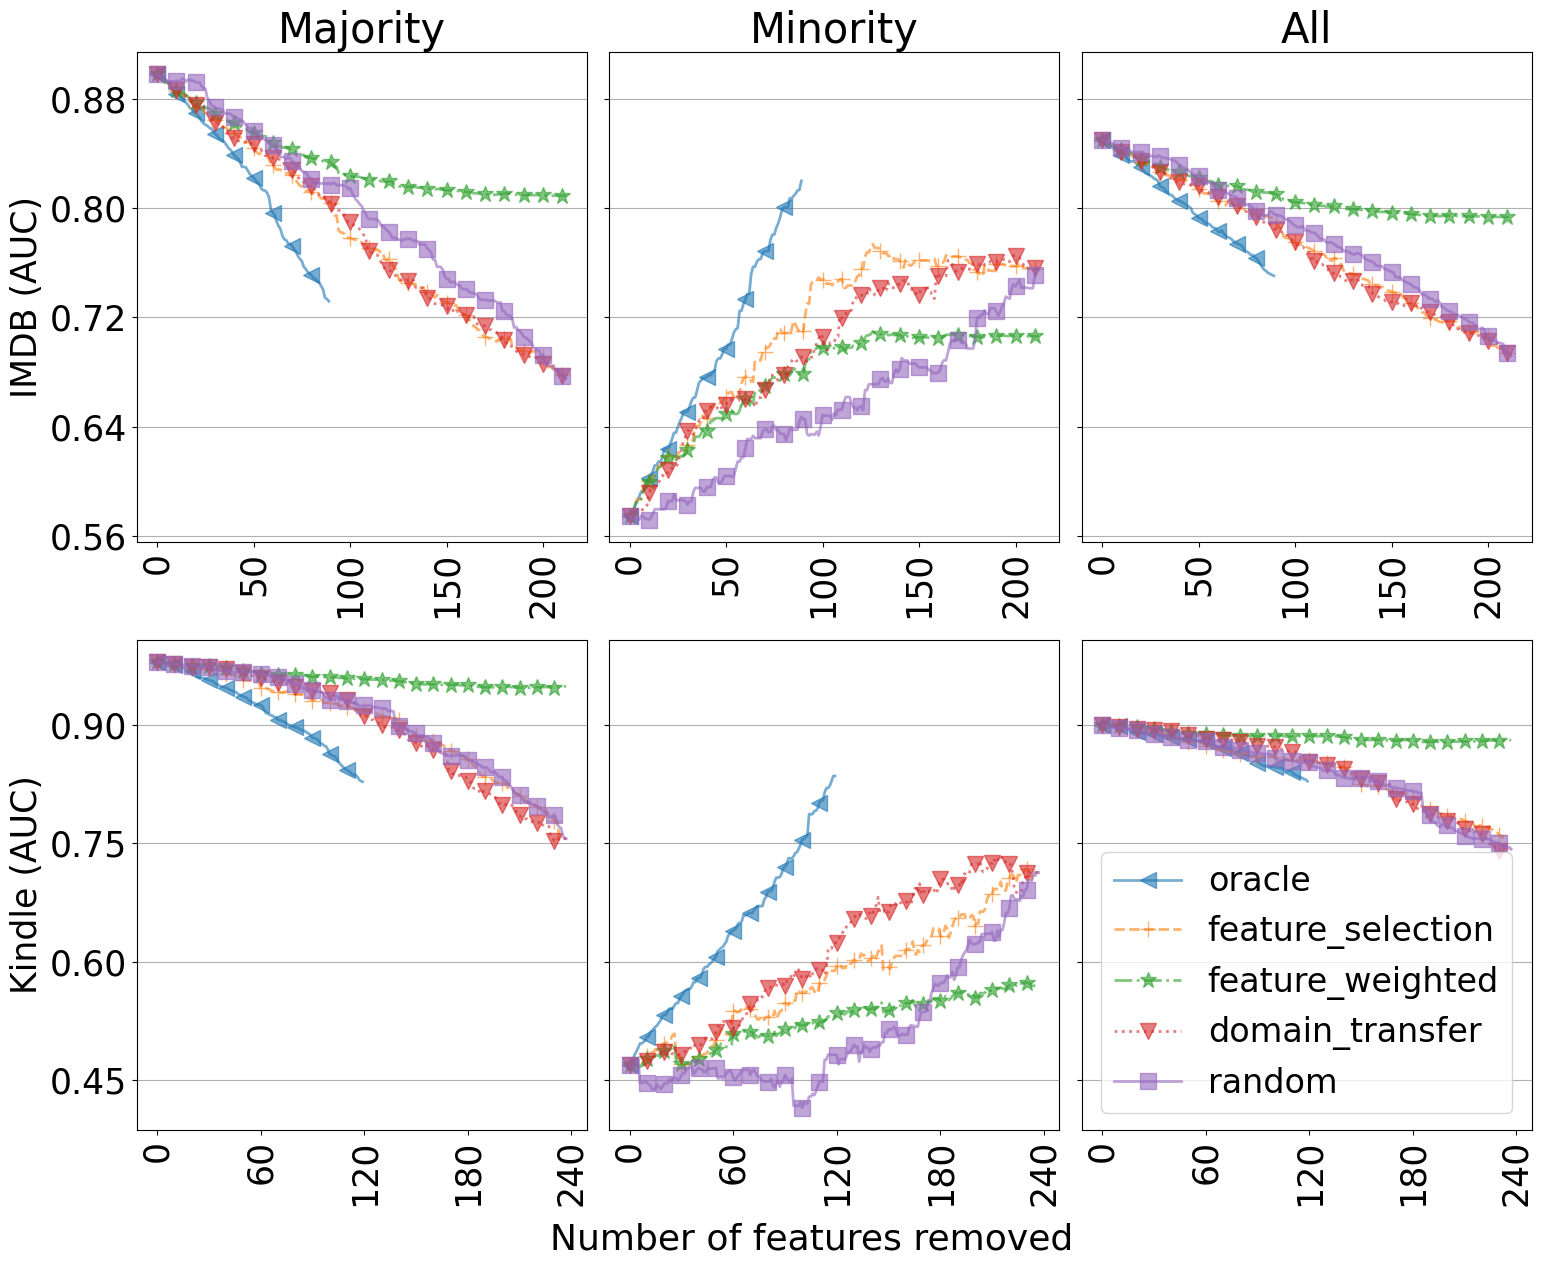

In [203]:
evaluate_feature_selection(task='sentiment',sample_by='priority')



 Toxic comment
Sampled 9129 train instances; 
test indices: (76 majority docs, 38 terms), (49 minority docs, 30 terms), intersection=0
Train distribution: Counter({-1: 4631, 1: 4498})
Test distribution: Counter({1: 76, -1: 49})
Majority distribution: Counter({1: 76})
Minority distribution: Counter({-1: 49})
Removed 3472 terms, 1156 remained
Majority: (0.618421052631579, ['read', 'however', 'gonna', 'agency', 'bit', 'visible', 'feet', 'implies', 'heterosexuals', 'doesn', 'lifestyle', 'under', 'brought', 'hours', 'medieval', 'regardless', 'types', 'silence', 'considered', 'done', 'climate', 'jim', 'play', 'campuses', 'blue', 'sell', 'yours', 'cardinal', 'cemetery', 'states', 'adultery', 'carried', 'common', 'usa', 'secondly', 'confirmed', 'wade', 'increasing', 'declare', 'participation', 'aspect', 'wanna', 'papers', 'become', 'meeting', 'fraction', 'this', 'nyc', 'arms', 'camps', 'whiners', 'starting', 'heroes', 'oh', 'south', 'core', 'conrad', 'journalists', 'bannon', 'criminals', 'get

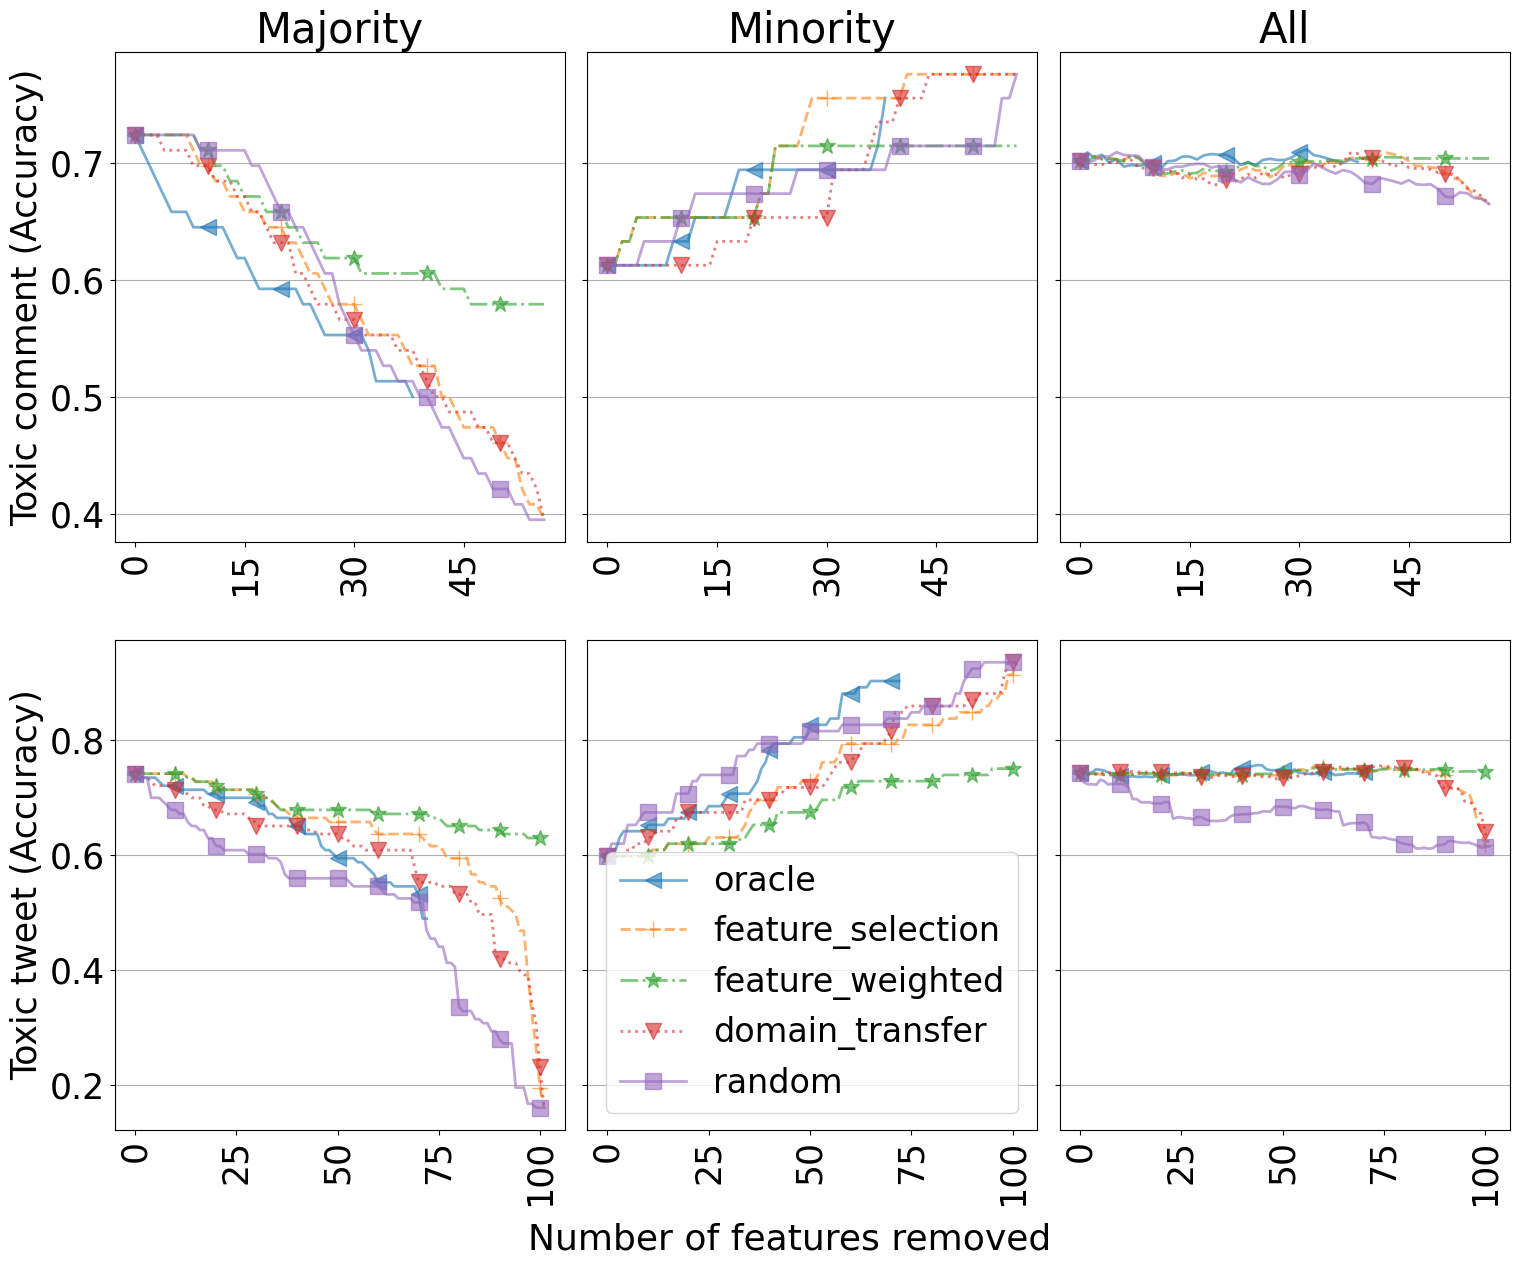

In [204]:
evaluate_feature_selection(task='toxic',sample_by='random')


In [205]:
[ds_kindle, ds_imdb, ds_toxic_tw, ds_toxic] = pickle.load(open('data/datasets_with_term_prob.pickle','rb'))


In [206]:
result_with_lexicon = []
for ds_data in [ds_imdb, ds_kindle, ds_toxic, ds_toxic_tw]:
    print('\n', ds_data.moniker)
    train_idx, majority_idx, minority_idx, maj_bad_terms, min_bad_terms = get_train_test_set(ds_data,smp_method='priority')
    test_idx = minority_idx + majority_idx
    word_counts = ds_data.X[test_idx].sum(axis=0).A1
    
    scores = {}
    for t_idx, t_col in zip([majority_idx, minority_idx, test_idx],['majority','minority','test']):
        val, rem_wds = feature_selection_by_lexicon(ds_data, train_idx, t_idx, feature_order='lexicon',word_counts=word_counts)
        scores[t_col] = float('%.3f' % val)
    result_with_lexicon.append(scores)
    

pd.DataFrame(result_with_lexicon).rename(index={0:'imdb',1:'kindle',2:'toxic_comment',3:'toxic_tweet'})


 imdb
Sample size for minority: 2
Sample size for majority: 7
Sampled 9904 train instances; 
test indices: (622 majority docs, 89 terms), (136 minority docs, 77 terms), intersection=0
Removed 3239 terms, 1335 remained
Removed 3239 terms, 1335 remained
Removed 3239 terms, 1335 remained

 kindle
Sample size for minority: 2
Sample size for majority: 5
Sampled 18967 train instances; 
test indices: (583 majority docs, 119 terms), (174 minority docs, 113 terms), intersection=0
Removed 1760 terms, 623 remained
Removed 1760 terms, 623 remained
Removed 1760 terms, 623 remained

 toxic
Sample size for minority: 2
Sample size for majority: 7
Sampled 14878 train instances; 
test indices: (266 majority docs, 38 terms), (72 minority docs, 37 terms), intersection=0
Removed 3472 terms, 1156 remained
Removed 3472 terms, 1156 remained
Removed 3472 terms, 1156 remained

 toxic_tw
Sample size for minority: 2
Sample size for majority: 5
Sampled 6288 train instances; 
test indices: (360 majority docs, 72 t

,majority,minority,test
imdb,0.734,0.702,0.730
kindle,0.830,0.709,0.803
toxic_comment,0.654,0.625,0.703
toxic_tweet,0.433,0.889,0.687


In [207]:
result_with_selection = []
for ds_data in [ds_imdb, ds_kindle, ds_toxic, ds_toxic_tw]:
    print('\n', ds_data.moniker)
    train_idx, majority_idx, minority_idx, maj_bad_terms, min_bad_terms = get_train_test_set(ds_data,smp_method='priority')
    test_idx = minority_idx + majority_idx
    word_counts = ds_data.X[test_idx].sum(axis=0).A1    
    
    scores = {}
    for t_idx, t_col in zip([majority_idx, minority_idx, test_idx],['majority','minority','test']):
        scores[t_col] = float('%.3f' % max(feature_selection(ds_data, train_idx, t_idx, feature_order='feature_selection')))
    result_with_selection.append(scores)
    
pd.DataFrame(result_with_selection).rename(index={0:'imdb',1:'kindle',2:'toxic_comment',3:'toxic_tweet'})


 imdb
Sample size for minority: 2
Sample size for majority: 7
Sampled 9904 train instances; 
test indices: (622 majority docs, 89 terms), (136 minority docs, 77 terms), intersection=0

 kindle
Sample size for minority: 2
Sample size for majority: 5
Sampled 18967 train instances; 
test indices: (583 majority docs, 119 terms), (174 minority docs, 113 terms), intersection=0

 toxic
Sample size for minority: 2
Sample size for majority: 7
Sampled 14878 train instances; 
test indices: (266 majority docs, 38 terms), (72 minority docs, 37 terms), intersection=0

 toxic_tw
Sample size for minority: 2
Sample size for majority: 5
Sampled 6288 train instances; 
test indices: (360 majority docs, 72 terms), (126 minority docs, 68 terms), intersection=0


,majority,minority,test
imdb,0.898,0.773,0.850
kindle,0.979,0.717,0.900
toxic_comment,0.703,0.861,0.776
toxic_tweet,0.747,0.937,0.781


In [208]:
ds_data = ds_toxic
train_idx, majority_idx, minority_idx, maj_bad_terms, min_bad_terms = get_train_test_set(ds_data,smp_method='priority')
test_idx = minority_idx + majority_idx
word_counts = ds_data.X[test_idx].sum(axis=0).A1    
score, toxic_terms_torem = feature_selection_by_lexicon(ds_data, train_idx, t_idx, feature_order='lexicon')

Sample size for minority: 2
Sample size for majority: 7
Sampled 14878 train instances; 
test indices: (266 majority docs, 38 terms), (72 minority docs, 37 terms), intersection=0
Removed 3472 terms, 1156 remained


In [209]:
print(toxic_terms_torem[:100])


['read', 'however', 'gonna', 'agency', 'bit', 'visible', 'feet', 'implies', 'heterosexuals', 'doesn', 'lifestyle', 'under', 'brought', 'hours', 'medieval', 'regardless', 'types', 'silence', 'considered', 'done', 'climate', 'jim', 'play', 'campuses', 'blue', 'sell', 'yours', 'cardinal', 'cemetery', 'states', 'adultery', 'carried', 'common', 'usa', 'secondly', 'confirmed', 'wade', 'increasing', 'declare', 'participation', 'aspect', 'wanna', 'papers', 'become', 'meeting', 'fraction', 'this', 'nyc', 'arms', 'camps', 'whiners', 'starting', 'heroes', 'oh', 'south', 'core', 'conrad', 'journalists', 'bannon', 'criminals', 'gets', 'sa', 'gave', 'resources', 'backwards', 'swamp', 'release', 'movement', 'le', 'either', 'page', 'intention', 'unborn', 'discovered', 'decide', 'rather', 'entrenched', 'advance', 'thou', 'thier', 'estate', 'nature', 'moore', 'number', 'leftists', 'weeks', 'yrs', 'goal', 'effort', 'charged', 'speech', 'relative', 'widely', 'leitch', 'leadership', 'section', 'primary', '

In [210]:
ds_data = ds_kindle
train_idx, majority_idx, minority_idx, maj_bad_terms, min_bad_terms = get_train_test_set(ds_data,smp_method='priority')
test_idx = minority_idx + majority_idx
word_counts = ds_data.X[test_idx].sum(axis=0).A1    
score, sentiment_terms_torem = feature_selection_by_lexicon(ds_data, train_idx, t_idx, feature_order='lexicon')

Sample size for minority: 2
Sample size for majority: 5
Sampled 18967 train instances; 
test indices: (583 majority docs, 119 terms), (174 minority docs, 113 terms), intersection=0
Removed 1760 terms, 623 remained


In [211]:
print(sentiment_terms_torem[:100])


['read', 'however', 'gonna', 'bit', 'chloe', 'doesn', 'lifestyle', 'under', 'sample', 'ties', 'tastes', 'brought', 'hours', 'regardless', 'types', 'considered', 'done', 'play', 'wouldnt', 'blue', 'sell', 'common', 'aspect', 'wanna', 'become', 'meeting', 'hangers', 'this', 'starting', 'heroes', 'oh', 'mildly', 'south', 'review', 'recipe', 'gets', 'gave', 'novels', 'angst', 'release', 'either', 'page', 'settings', 'decide', 'rather', 'alot', 'expecting', 'estate', 'graphics', 'ian', 'nature', 'number', 'weeks', 'effort', 'charged', 'reminded', 'section', 'tho', 'somehow', 'simply', 'also', 'dom', 'roller', 'john', 'me', 'often', 'message', 'wolves', 'scenario', 'journal', 'out', 'writers', 'fi', '3rd', 'series', 'paperwhite', 'fairy', 'within', 'continues', 'coaster', '4th', 'elizabeth', 'suspenseful', 'tie', 'older', 'own', 'surprises', 'released', 'board', 'ran', 'experience', 'step', 'valentine', 'speak', 'hd', 'rhyme', 'everyday', 'comment', 'cake', 'purchased']


In [212]:
!pip freeze

adjustText==1.3.0
appnope==0.1.4
asttokens==3.0.0
certifi==2025.1.31
charset-normalizer==3.4.1
comm==0.2.2
contourpy==1.3.0
cycler==0.12.1
debugpy==1.8.13
decorator==5.2.1
exceptiongroup==1.2.2
executing==2.2.0
filelock==3.17.0
fonttools==4.56.0
fsspec==2025.2.0
huggingface-hub==0.29.2
idna==3.10
importlib-metadata==8.6.1
importlib-resources==6.5.2
ipykernel==6.29.5
ipython==8.18.1
ipywidgets==8.1.5
jedi==0.19.2
jinja2==3.1.6
joblib==1.4.2
jupyter-client==8.6.3
jupyter-core==5.7.2
jupyterlab-widgets==3.0.13
kiwisolver==1.4.7
markupsafe==3.0.2
matplotlib==3.9.4
matplotlib-inline==0.1.7
mpmath==1.3.0
nest-asyncio==1.6.0
networkx==3.2.1
numpy==1.24.1
packaging==24.2
pandas==1.5.3
parso==0.8.4
pexpect==4.9.0
pillow==11.1.0
platformdirs==4.3.6
prompt-toolkit==3.0.50
psutil==7.0.0
ptyprocess==0.7.0
pure-eval==0.2.3
pygments==2.19.1
pyparsing==3.2.1
python-dateutil==2.9.0.post0
pytz==2025.1
PyYAML==6.0.2
pyzmq==26.2.1
regex==2024.11.6
requests==2.32.3
safetensors==0.5.3
scikit-learn==1.6.1
sc

In [215]:
import numpy as np
import pandas as pd
import re
import random

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

from sentence_transformers import SentenceTransformer, util

# ------------------------------
# 1. Data Preparation and Baseline Document Classifier
# ------------------------------

# For reproducibility
random.seed(42)
np.random.seed(42)

# Create a toy dataset (binary sentiment: 1=positive, 0=negative)
sentences = [
    "This movie is amazing and wonderful",
    "The film was boring and dull",
    "Spielberg directed an amazing film",
    "Seagal appears in a typical action movie",
    "What a wonderful and inspiring performance",
    "The plot was dull and uninteresting",
    "An amazing film by a visionary director",
    "The movie was boring and overly long",
    "Spielberg brings magic to every film",
    "Seagal is typical of action movies",
]
labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(sentences, labels, test_size=0.3, random_state=42)

# Use a simple bag-of-words representation.
vectorizer = CountVectorizer(lowercase=True, stop_words='english')
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

# Train a logistic regression document classifier.
doc_clf = LogisticRegression(max_iter=200)
doc_clf.fit(X_train_counts, y_train)

# Evaluate baseline performance.
y_pred = doc_clf.predict(X_test_counts)
baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_auc = roc_auc_score(y_test, doc_clf.predict_proba(X_test_counts)[:, 1])
print("Baseline Document Classifier Accuracy: {:.2f}".format(baseline_accuracy))
print("Baseline Document Classifier AUC: {:.2f}".format(baseline_auc))

# ------------------------------
# 2. Extract Candidate Words Based on Model Coefficients
# ------------------------------

# Get coefficient values from the logistic regression.
coef = doc_clf.coef_[0]
vocab = np.array(vectorizer.get_feature_names_out())

# Here we select the top N candidate words based on the absolute value of coefficients.
num_candidates = 6
top_indices = np.argsort(np.abs(coef))[::-1][:num_candidates]
candidate_words = vocab[top_indices]
print("\nCandidate Words from Initial Classifier:")
print(candidate_words)

# ------------------------------
# 3. Setup SentenceTransformer for Context Embeddings
# ------------------------------

# Choose a pretrained model (e.g., all-MiniLM-L6-v2, a light model for demo purposes)
model_name = 'all-MiniLM-L6-v2'
embedder = SentenceTransformer(model_name)

# Define a helper function to extract the word context.
def extract_context(sentence, target_word, window=5):
    """
    Extract the context surrounding the target word within the given window.
    Returns a list of context strings (if the target appears more than once).
    """
    words = sentence.split()
    # Find all positions of the target word (case-insensitive).
    indices = [i for i, word in enumerate(words) if word.lower() == target_word.lower()]
    contexts = []
    for idx in indices:
        start = max(0, idx - window)
        end = min(len(words), idx + window + 1)
        # Exclude the target word itself.
        context = words[start:idx] + words[idx+1:end]
        contexts.append(" ".join(context))
    return contexts

# ------------------------------
# 4. Matching and Feature Computation for Candidate Words
# ------------------------------

def perform_matching(word, sentences, labels):
    """
    For each sentence containing 'word', find a matching sentence (that does not contain the word)
    based on context similarity. Compute:
      - The average cosine similarity between the context embeddings.
      - An approximate average treatment effect (ATE) computed as: label(s) - average label of candidate matches.
      - Count of matches found.
    """
    similarities = []
    treatment_effects = []
    count_matches = 0
    
    for i, sentence in enumerate(sentences):
        if re.search(r'\b' + re.escape(word.lower()) + r'\b', sentence.lower()):
            # Extract context(s) for occurrences of the word.
            contexts = extract_context(sentence, word)
            if not contexts:
                continue
            context_embeddings = embedder.encode(contexts)
            # Find candidate sentences that do NOT contain the word.
            candidate_indices = [j for j, s in enumerate(sentences) if word.lower() not in s.lower()]
            if not candidate_indices:
                continue
            candidate_contexts = []
            # Here, we simply use the whole sentence (or a fixed window) for candidates.
            for j in candidate_indices:
                # For a candidate sentence without the word, use a simple context (here the full sentence)
                candidate_contexts.append(sentences[j])
            candidate_embeddings = embedder.encode(candidate_contexts)
            # For each occurrence in the current sentence, compute cosine similarity with candidate embeddings.
            for emb in context_embeddings:
                cos_sim = cosine_similarity([emb], candidate_embeddings)
                max_sim = np.max(cos_sim)
                similarities.append(max_sim)
                # For treatment effect, here we approximate by taking the average candidate label.
                candidate_labels = [labels[j] for j in candidate_indices]
                best_label = np.mean(candidate_labels)  # simplified proxy for the match.
                treatment_effect = labels[i] - best_label
                treatment_effects.append(treatment_effect)
                count_matches += 1
    
    if count_matches == 0:
        avg_similarity = 0.0
        avg_treatment_effect = 0.0
    else:
        avg_similarity = np.mean(similarities)
        avg_treatment_effect = np.mean(treatment_effects)
    return avg_similarity, avg_treatment_effect, count_matches

# Compute features for each candidate word.
features = []
for word in candidate_words:
    avg_sim, avg_ate, match_count = perform_matching(word, X_train, y_train)
    # Also include the coefficient from the document classifier as a feature.
    word_coef = coef[list(vocab).index(word)]
    features.append({
        'word': word,
        'avg_similarity': avg_sim,
        'avg_ate': avg_ate,
        'match_count': match_count,
        'word_coef': word_coef
    })

df_features = pd.DataFrame(features)
print("\nCandidate Word Features:")
print(df_features)

# ------------------------------
# 5. Train a Word Classifier Using Simulated Human Labels
# ------------------------------

# In practice, these labels would come from human annotation.
# For this demo, we simulate labels by assuming that words like "spielberg" and "seagal" are spurious.
# Let spurious words get label 1, genuine ones get label 0.
word_label_mapping = {word: (1 if word.lower() in ['spielberg', 'seagal'] else 0) for word in candidate_words}
df_features['spurious_label'] = df_features['word'].apply(lambda w: word_label_mapping.get(w, 0))
print("\nFeatures with Simulated Human Labels:")
print(df_features)

# Train a logistic regression word classifier.
word_feature_columns = ['avg_similarity', 'avg_ate', 'match_count', 'word_coef']
X_word = df_features[word_feature_columns].values
y_word = df_features['spurious_label'].values

word_clf = LogisticRegression()
word_clf.fit(X_word, y_word)
df_features['predicted_spurious_prob'] = word_clf.predict_proba(X_word)[:, 1]
print("\nWord Classifier Predictions:")
print(df_features[['word', 'predicted_spurious_prob']])

# ------------------------------
# 6. Feature Selection for the Document Classifier
# ------------------------------

# We simulate feature selection by removing words predicted as spurious (probability > threshold).
spurious_threshold = 0.5
words_to_remove = df_features[df_features['predicted_spurious_prob'] > spurious_threshold]['word'].tolist()
print("\nWords predicted as spurious and to be removed:", words_to_remove)

# Rebuild the CountVectorizer so that it excludes the spurious words.
def custom_preprocessor(text):
    # Remove spurious words based on the list (case-insensitive).
    pattern = r'\b(?:' + '|'.join(words_to_remove) + r')\b'
    return re.sub(pattern, '', text, flags=re.IGNORECASE)

vectorizer_fs = CountVectorizer(lowercase=True, stop_words='english', preprocessor=custom_preprocessor)
X_train_fs = vectorizer_fs.fit_transform(X_train)
X_test_fs = vectorizer_fs.transform(X_test)

doc_clf_fs = LogisticRegression(max_iter=200)
doc_clf_fs.fit(X_train_fs, y_train)

y_pred_fs = doc_clf_fs.predict(X_test_fs)
fs_accuracy = accuracy_score(y_test, y_pred_fs)
fs_auc = roc_auc_score(y_test, doc_clf_fs.predict_proba(X_test_fs)[:, 1])
print("\nDocument Classifier after Feature Selection:")
print("  Accuracy: {:.2f}".format(fs_accuracy))
print("  AUC: {:.2f}".format(fs_auc))

Baseline Document Classifier Accuracy: 0.33
Baseline Document Classifier AUC: 1.00

Candidate Words from Initial Classifier:
['amazing' 'action' 'seagal' 'typical' 'wonderful' 'film']


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

loading file vocab.txt from cache at /Users/rahul/.cache/huggingface/hub/models--sentence-transformers--all-MiniLM-L6-v2/snapshots/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/vocab.txt
loading file tokenizer.json from cache at /Users/rahul/.cache/huggingface/hub/models--sentence-transformers--all-MiniLM-L6-v2/snapshots/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/tokenizer.json
loading file added_tokens.json from cache at None
loading file special_tokens_map.json from cache at /Users/rahul/.cache/huggingface/hub/models--sentence-transformers--all-MiniLM-L6-v2/snapshots/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/special_tokens_map.json
loading file tokenizer_config.json from cache at /Users/rahul/.cache/huggingface/hub/models--sentence-transformers--all-MiniLM-L6-v2/snapshots/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/tokenizer_config.json
loading file chat_template.jinja from cache at None


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Candidate Word Features:
        word  avg_similarity  avg_ate  match_count  word_coef
0  amazing    0.379286        0.75     3            0.555025 
1  action     0.354538       -0.80     2           -0.448053 
2  seagal     0.298418       -0.80     2           -0.448053 
3  typical    0.362835       -0.80     2           -0.448053 
4  wonderful  0.513118        0.60     2            0.444703 
5  film       0.536626        0.60     2            0.319927 

Features with Simulated Human Labels:
        word  avg_similarity  avg_ate  match_count  word_coef  spurious_label
0  amazing    0.379286        0.75     3            0.555025   0             
1  action     0.354538       -0.80     2           -0.448053   0             
2  seagal     0.298418       -0.80     2           -0.448053   1             
3  typical    0.362835       -0.80     2           -0.448053   0             
4  wonderful  0.513118        0.60     2            0.444703   0             
5  film       0.536626        0.6

In [1]:
import numpy as np
import pandas as pd
import re
import random

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

from sentence_transformers import SentenceTransformer, util
import tensorflow_datasets as tfds

# ------------------------------
# 1. Data Preparation and Baseline Document Classifier on IMDB Dataset
# ------------------------------

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

# Load the IMDB dataset using Hugging Face datasets
# imdb = load_dataset("imdb")
train_data, test_data = tfds.load("imdb_reviews", split=["train", "test"], as_supervised=True)


# For demonstration purposes, sub-sample a smaller portion of data.
# (The full dataset contains 25,000 reviews for each split.)
# We sample 1000 training samples and 200 test samples.

# Extract text and labels (the IMDB labels are 0 for negative and 1 for positive)
X_train = [item['text'] for item in train_data]
y_train = [item['label'] for item in train_data]
X_test  = [item['text'] for item in test_data]
y_test  = [item['label'] for item in test_data]

# Use a simple bag-of-words representation (remove English stop words)
vectorizer = CountVectorizer(lowercase=True, stop_words='english')
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts  = vectorizer.transform(X_test)

# Train a baseline logistic regression document classifier.
doc_clf = LogisticRegression(max_iter=200)
doc_clf.fit(X_train_counts, y_train)

# Evaluate baseline performance.
y_pred = doc_clf.predict(X_test_counts)
baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_auc = roc_auc_score(y_test, doc_clf.predict_proba(X_test_counts)[:, 1])
print("Baseline Document Classifier Accuracy: {:.2f}".format(baseline_accuracy))
print("Baseline Document Classifier AUC: {:.2f}".format(baseline_auc))

# ------------------------------
# 2. Extract Candidate Words Based on Model Coefficients
# ------------------------------

# Get coefficients from the logistic regression.
coef = doc_clf.coef_[0]
vocab = np.array(vectorizer.get_feature_names_out())

# Select the top N candidate words based on the absolute value of coefficients.
num_candidates = 10  # increase number for a richer candidate set
top_indices = np.argsort(np.abs(coef))[::-1][:num_candidates]
candidate_words = vocab[top_indices]
print("\nCandidate Words from Initial Classifier:")
print(candidate_words)

# ------------------------------
# 3. Setup SentenceTransformer for Context Embeddings
# ------------------------------

# Use a light model (all-MiniLM-L6-v2) suitable for demonstration.
model_name = 'all-MiniLM-L6-v2'
embedder = SentenceTransformer(model_name)

# Helper function: extract the context surrounding the target word.
def extract_context(sentence, target_word, window=5):
    """
    Extract the context surrounding the target word within the given window.
    Returns a list of context strings (for all occurrences).
    """
    words = sentence.split()
    # Find all indices matching the target word (case-insensitive).
    indices = [i for i, word in enumerate(words) if word.lower() == target_word.lower()]
    contexts = []
    for idx in indices:
        start = max(0, idx - window)
        end = min(len(words), idx + window + 1)
        # Remove the target word itself.
        context = words[start:idx] + words[idx+1:end]
        contexts.append(" ".join(context))
    return contexts

# ------------------------------
# 4. Matching and Feature Computation for Candidate Words
# ------------------------------

def perform_matching(word, sentences, labels):
    """
    For each review (sentence) that contains the target 'word', find matching reviews that do not contain it.
    Compute features:
      - Average cosine similarity between the context embeddings.
      - Approximate average treatment effect (ATE), computed as: label(s) - average candidate label.
      - Count of matching instances.
    """
    similarities = []
    treatment_effects = []
    count_matches = 0
    
    for i, sentence in enumerate(sentences):
        # Use a regex search for the target word (case-insensitive)
        if re.search(r'\b' + re.escape(word.lower()) + r'\b', sentence.lower()):
            # Extract context(s) around each occurrence.
            contexts = extract_context(sentence, word)
            if not contexts:
                continue
            context_embeddings = embedder.encode(contexts, convert_to_numpy=True)
            # Identify candidate reviews that do NOT contain the word.
            candidate_indices = [j for j, s in enumerate(sentences) if word.lower() not in s.lower()]
            if not candidate_indices:
                continue
            candidate_texts = [sentences[j] for j in candidate_indices]
            candidate_embeddings = embedder.encode(candidate_texts, convert_to_numpy=True)
            
            # For each occurrence, compute cosine similarity with candidate reviews.
            for emb in context_embeddings:
                cos_sim = cosine_similarity([emb], candidate_embeddings)
                max_sim = np.max(cos_sim)
                similarities.append(max_sim)
                # Approximate treatment effect: difference between current review label and average candidate label.
                candidate_labels = [labels[j] for j in candidate_indices]
                best_label = np.mean(candidate_labels)  # simplified proxy
                treatment_effect = labels[i] - best_label
                treatment_effects.append(treatment_effect)
                count_matches += 1
    
    if count_matches == 0:
        avg_similarity = 0.0
        avg_treatment_effect = 0.0
    else:
        avg_similarity = np.mean(similarities)
        avg_treatment_effect = np.mean(treatment_effects)
    return avg_similarity, avg_treatment_effect, count_matches

# Compute features for each candidate word.
features = []
for word in candidate_words:
    avg_sim, avg_ate, match_count = perform_matching(word, X_train, y_train)
    # Include the word's coefficient from the document classifier.
    word_coef = coef[list(vocab).index(word)]
    features.append({
        'word': word,
        'avg_similarity': avg_sim,
        'avg_ate': avg_ate,
        'match_count': match_count,
        'word_coef': word_coef
    })

df_features = pd.DataFrame(features)
print("\nCandidate Word Features:")
print(df_features)

# ------------------------------
# 5. Train a Word Classifier Using Simulated Human Labels
# ------------------------------

# In a real scenario, these labels would be obtained via human annotation.
# For demonstration, we simulate spurious labels by assuming that words
# such as "spielberg" and "seagal" are spurious. (Adjust or simulate for your candidate set.)
word_label_mapping = {word: (1 if word.lower() in ['spielberg', 'seagal'] else 0) for word in candidate_words}
df_features['spurious_label'] = df_features['word'].apply(lambda w: word_label_mapping.get(w, 0))
print("\nFeatures with Simulated Human Labels:")
print(df_features)

# Train a logistic regression word classifier.
word_feature_columns = ['avg_similarity', 'avg_ate', 'match_count', 'word_coef']
X_word = df_features[word_feature_columns].values
y_word = df_features['spurious_label'].values

word_clf = LogisticRegression()
word_clf.fit(X_word, y_word)
df_features['predicted_spurious_prob'] = word_clf.predict_proba(X_word)[:, 1]
print("\nWord Classifier Predictions:")
print(df_features[['word', 'predicted_spurious_prob']])

# ------------------------------
# 6. Feature Selection for the Document Classifier
# ------------------------------

# Remove candidate words predicted as spurious (probability > threshold).
spurious_threshold = 0.5
words_to_remove = df_features[df_features['predicted_spurious_prob'] > spurious_threshold]['word'].tolist()
print("\nWords predicted as spurious and to be removed:", words_to_remove)

# Rebuild CountVectorizer to remove these words using a custom preprocessor.
def custom_preprocessor(text):
    pattern = r'\b(?:' + '|'.join(words_to_remove) + r')\b'
    return re.sub(pattern, '', text, flags=re.IGNORECASE)

vectorizer_fs = CountVectorizer(lowercase=True, stop_words='english', preprocessor=custom_preprocessor)
X_train_fs = vectorizer_fs.fit_transform(X_train)
X_test_fs  = vectorizer_fs.transform(X_test)

doc_clf_fs = LogisticRegression(max_iter=200)
doc_clf_fs.fit(X_train_fs, y_train)

y_pred_fs = doc_clf_fs.predict(X_test_fs)
fs_accuracy = accuracy_score(y_test, y_pred_fs)
fs_auc = roc_auc_score(y_test, doc_clf_fs.predict_proba(X_test_fs)[:, 1])
print("\nDocument Classifier after Feature Selection:")
print("  Accuracy: {:.2f}".format(fs_accuracy))
print("  AUC: {:.2f}".format(fs_auc))

In [2]:
!pip freeze > requirements.txt